# Notebook 3: Model Building and Hyperparameter Tuning

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve,
                              precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
os.makedirs('plots', exist_ok=True)
print("Libraries loaded. Optuna version:", optuna.__version__)

Libraries loaded. Optuna version: 4.9.0


/opt/anaconda3/envs/churn-prediction-threshold-optimisation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data

In [3]:
# Load pre-split data saved by Notebook 2
# Order must match the dump in Notebook 2 exactly:
#   (X_train, X_val, X_test, y_train, y_val, y_test, X_train_smote, y_train_smote)
with open('data/train_val_test_split.pkl', 'rb') as f:
    (X_train, X_val, X_test,
     y_train, y_val, y_test,
     X_train_smote, y_train_smote) = pickle.load(f)

# Alias kept so the rest of Notebook 3 reads clearly: "_raw" = pre-SMOTE
X_train_raw, y_train_raw = X_train, y_train

splits = [
    ("Train (raw, pre-SMOTE)", X_train_raw,   y_train_raw),
    ("Train (SMOTE-balanced)", X_train_smote, y_train_smote),
    ("Validation",             X_val,         y_val),
    ("Test",                   X_test,        y_test),
]

print(f"{'Split':<26}{'Shape':<16}{'Churn rate':>11}")
print("-" * 53)
for name, X, y in splits:
    print(f"{name:<26}{str(X.shape):<16}{pd.Series(y).mean()*100:>10.1f}%")

total = len(X_train_raw) + len(X_val) + len(X_test)
print(f"\nSplit proportions: {len(X_train_raw)/total:.0%} train / "
      f"{len(X_val)/total:.0%} val / {len(X_test)/total:.0%} test   (n = {total:,})")

# Fail loudly rather than silently producing invalid results
assert len(set(X_train_raw.index) & set(X_val.index))  == 0, "Train/val overlap!"
assert len(set(X_train_raw.index) & set(X_test.index)) == 0, "Train/test overlap!"
assert len(set(X_val.index)       & set(X_test.index)) == 0, "Val/test overlap!"
assert list(X_train_raw.columns) == list(X_val.columns) == list(X_test.columns)
print("Split integrity checks passed — no index overlap, columns aligned.")

Split                     Shape            Churn rate
-----------------------------------------------------
Train (raw, pre-SMOTE)    (4219, 23)            26.6%
Train (SMOTE-balanced)    (6196, 23)            50.0%
Validation                (1406, 23)            26.6%
Test                      (1407, 23)            26.6%

Split proportions: 60% train / 20% val / 20% test   (n = 7,032)
Split integrity checks passed — no index overlap, columns aligned.


## 3. Evaluation Utilities

`select_threshold` is fitted on **validation probabilities only**. `evaluate_on_test`
then applies that frozen threshold to the test set. Keeping these as two separate
functions makes it structurally difficult to accidentally tune on test.

In [4]:
def full_evaluate(model_name, y_true, y_prob, threshold=0.5):
    """Compute all evaluation metrics at a given (already-chosen) threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model':     model_name,
        'Threshold': threshold,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob),
        'PR-AUC':    average_precision_score(y_true, y_prob),
    }


def find_best_threshold(y_true, y_prob, metric='f1'):
    """Scan thresholds and return the one maximising `metric` on the data given.

    NOTE: pass VALIDATION data here when selecting an operating point.
    It is only ever called with y_test in Section 6.6, where the explicit
    purpose is to quantify the optimism of test-set threshold tuning.
    """
    thresholds = np.arange(0.10, 0.90, 0.01)
    best_score, best_thr = -1.0, 0.5
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred, zero_division=0)
        elif metric == 'youden':
            score = (recall_score(y_true, y_pred, zero_division=0)
                     - (1 - recall_score(1 - np.asarray(y_true),
                                         1 - y_pred, zero_division=0)))
        else:
            raise ValueError(f"Unknown metric: {metric}")
        if score > best_score:
            best_score, best_thr = score, round(float(thr), 2)
    return best_thr, best_score


def select_threshold(model, X_val, y_val, metric='f1'):
    """Choose the operating threshold using the VALIDATION set only."""
    val_prob = model.predict_proba(X_val)[:, 1]
    thr, val_score = find_best_threshold(y_val, val_prob, metric=metric)
    return thr, val_score, val_prob


def evaluate_on_test(name, model, X_test, y_test, threshold,
                     results_store, probs_store, report=True):
    """Apply a FROZEN threshold to the test set and record the metrics."""
    test_prob = model.predict_proba(X_test)[:, 1]
    metrics = full_evaluate(name, y_test, test_prob, threshold)
    results_store[name] = metrics
    probs_store[name] = test_prob
    if report:
        print(classification_report(y_test, (test_prob >= threshold).astype(int),
                                    target_names=['No Churn', 'Churn'], digits=4))
    return metrics, test_prob


def fit_select_evaluate(name, model, metric='f1', report=True,
                        results_store=None, probs_store=None,
                        val_probs_store=None, thr_store=None):
    """Full pipeline: threshold from validation -> frozen -> applied to test."""
    thr, val_score, val_prob = select_threshold(model, X_val, y_val, metric=metric)
    print(f"{name}")
    print(f"  Validation-optimal threshold : {thr:.2f}  (val {metric.upper()} = {val_score:.4f})")
    metrics, test_prob = evaluate_on_test(name, model, X_test, y_test, thr,
                                          results_store, probs_store, report=report)
    if val_probs_store is not None:
        val_probs_store[name] = val_prob
    if thr_store is not None:
        thr_store[name] = thr
    return thr, metrics, val_prob, test_prob


CV_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Baseline stores
baseline_all_results, baseline_all_probs = {}, {}
baseline_val_probs,   baseline_thresholds = {}, {}

# Tuned-model stores
all_results, all_probs = {}, {}
val_probs,   thresholds_used = {}, {}

print("Utility functions defined.")

Utility functions defined.


## 4. Baseline Models (SMOTE data, default hyperparameters)

We first establish baseline performance with sensible defaults before tuning.

Sensible defaults, no hyperparameter search. Fitted on the SMOTE-balanced training
set; threshold picked on validation; reported on test.

### 4.1 Random Forest — Baseline

In [5]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_baseline.fit(X_train_smote, y_train_smote)

thr_rf_base, _, rf_val_prob, rf_prob_test = fit_select_evaluate(
    'RF Baseline (val-opt thr)', rf_baseline,
    results_store=baseline_all_results, probs_store=baseline_all_probs,
    val_probs_store=baseline_val_probs, thr_store=baseline_thresholds)

RF Baseline (val-opt thr)
  Validation-optimal threshold : 0.37  (val F1 = 0.5896)
              precision    recall  f1-score   support

    No Churn     0.9072    0.6999    0.7902      1033
       Churn     0.4918    0.8021    0.6098       374

    accuracy                         0.7271      1407
   macro avg     0.6995    0.7510    0.7000      1407
weighted avg     0.7967    0.7271    0.7422      1407



In [6]:
# Same model at the conventional 0.50 cut-off, for reference
_ = evaluate_on_test('RF Baseline (thr=0.50)', rf_baseline, X_test, y_test, 0.50,
                     baseline_all_results, baseline_all_probs)
baseline_thresholds['RF Baseline (thr=0.50)'] = 0.50
baseline_val_probs['RF Baseline (thr=0.50)'] = rf_val_prob

              precision    recall  f1-score   support

    No Churn     0.8688    0.8141    0.8406      1033
       Churn     0.5626    0.6604    0.6076       374

    accuracy                         0.7733      1407
   macro avg     0.7157    0.7373    0.7241      1407
weighted avg     0.7874    0.7733    0.7787      1407



### 4.2 XGBoost — Baseline

In [7]:
scale_pw = y_train_raw.value_counts()[0] / y_train_raw.value_counts()[1]
print(f"scale_pos_weight (from raw train): {scale_pw:.3f}")

xgb_baseline = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_baseline.fit(X_train_smote, y_train_smote)

thr_xgb_base, _, xgb_val_prob, xgb_prob_test = fit_select_evaluate(
    'XGB Baseline (val-opt thr)', xgb_baseline,
    results_store=baseline_all_results, probs_store=baseline_all_probs,
    val_probs_store=baseline_val_probs, thr_store=baseline_thresholds)

scale_pos_weight (from raw train): 2.764
XGB Baseline (val-opt thr)
  Validation-optimal threshold : 0.31  (val F1 = 0.5890)
              precision    recall  f1-score   support

    No Churn     0.9229    0.6254    0.7455      1033
       Churn     0.4526    0.8556    0.5920       374

    accuracy                         0.6866      1407
   macro avg     0.6877    0.7405    0.6688      1407
weighted avg     0.7979    0.6866    0.7047      1407



In [8]:
_ = evaluate_on_test('XGB Baseline (thr=0.50)', xgb_baseline, X_test, y_test, 0.50,
                     baseline_all_results, baseline_all_probs)
baseline_thresholds['XGB Baseline (thr=0.50)'] = 0.50
baseline_val_probs['XGB Baseline (thr=0.50)'] = xgb_val_prob

              precision    recall  f1-score   support

    No Churn     0.9010    0.7222    0.8017      1033
       Churn     0.5043    0.7807    0.6128       374

    accuracy                         0.7377      1407
   macro avg     0.7026    0.7515    0.7073      1407
weighted avg     0.7955    0.7377    0.7515      1407



### 4.3 CatBoost — Baseline

In [9]:
cat_scale_pw = y_train_raw.value_counts()[0] / y_train_raw.value_counts()[1]

cat_baseline = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    class_weights=[1.0, cat_scale_pw],
    random_state=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)
cat_baseline.fit(X_train_smote, y_train_smote)

thr_cat_base, _, cat_val_prob, cat_prob_test = fit_select_evaluate(
    'CAT Baseline (val-opt thr)', cat_baseline,
    results_store=baseline_all_results, probs_store=baseline_all_probs,
    val_probs_store=baseline_val_probs, thr_store=baseline_thresholds)

CAT Baseline (val-opt thr)
  Validation-optimal threshold : 0.54  (val F1 = 0.6048)
              precision    recall  f1-score   support

    No Churn     0.9166    0.6912    0.7881      1033
       Churn     0.4920    0.8262    0.6168       374

    accuracy                         0.7271      1407
   macro avg     0.7043    0.7587    0.7024      1407
weighted avg     0.8037    0.7271    0.7425      1407



In [10]:
_ = evaluate_on_test('CAT Baseline (thr=0.50)', cat_baseline, X_test, y_test, 0.50,
                     baseline_all_results, baseline_all_probs)
baseline_thresholds['CAT Baseline (thr=0.50)'] = 0.50
baseline_val_probs['CAT Baseline (thr=0.50)'] = cat_val_prob

              precision    recall  f1-score   support

    No Churn     0.9275    0.6689    0.7773      1033
       Churn     0.4834    0.8556    0.6178       374

    accuracy                         0.7186      1407
   macro avg     0.7055    0.7623    0.6975      1407
weighted avg     0.8095    0.7186    0.7349      1407



### 4.4 Baseline Comparison

In [11]:
display_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
baseline_df = pd.DataFrame(baseline_all_results).T

print("\n" + "=" * 78)
print("BASELINE MODELS - TEST SET PERFORMANCE (thresholds selected on validation)")
print("=" * 78)
print(baseline_df[['Threshold'] + display_cols].round(4).to_string())

print("\n-> Best per metric:")
for col in display_cols:
    best_model = baseline_df[display_cols].astype(float)[col].idxmax()
    print(f"   {col:12s}: {best_model} ({float(baseline_df.loc[best_model, col]):.4f})")


BASELINE MODELS - TEST SET PERFORMANCE (thresholds selected on validation)
                           Threshold  Accuracy Precision    Recall        F1   ROC-AUC    PR-AUC
RF Baseline (val-opt thr)       0.37  0.727079  0.491803  0.802139  0.609756  0.820224  0.602282
RF Baseline (thr=0.50)           0.5  0.773276  0.562642  0.660428  0.607626  0.820224  0.602282
XGB Baseline (val-opt thr)      0.31  0.686567  0.452617  0.855615  0.592044  0.823536  0.613009
XGB Baseline (thr=0.50)          0.5   0.73774  0.504318  0.780749  0.612802  0.823536  0.613009
CAT Baseline (val-opt thr)      0.54  0.727079  0.492038  0.826203  0.616766  0.837483  0.645603
CAT Baseline (thr=0.50)          0.5   0.71855  0.483384  0.855615  0.617761  0.837483  0.645603

-> Best per metric:
   Accuracy    : RF Baseline (thr=0.50) (0.7733)
   Precision   : RF Baseline (thr=0.50) (0.5626)
   Recall      : XGB Baseline (val-opt thr) (0.8556)
   F1          : CAT Baseline (thr=0.50) (0.6178)
   ROC-AUC     : CAT Ba

In [12]:
# Build plot labels dynamically from the actual selected thresholds -
# nothing here is hard-coded, so it stays correct if the split or seed changes.
metrics_df = pd.DataFrame(baseline_all_results).T[display_cols].astype(float)

family_of = {
    'RF Baseline (val-opt thr)' : 'RF',
    'RF Baseline (thr=0.50)'    : 'RF',
    'XGB Baseline (val-opt thr)': 'XGB',
    'XGB Baseline (thr=0.50)'   : 'XGB',
    'CAT Baseline (val-opt thr)': 'CAT',
    'CAT Baseline (thr=0.50)'   : 'CAT',
}
family_colour = {'RF': '#1565C0', 'XGB': '#E65100', 'CAT': '#1B5E20'}
family_colour_light = {'RF': '#90CAF9', 'XGB': '#FFB74D', 'CAT': '#A5D6A7'}

short_labels, colours = [], []
for m in metrics_df.index:
    fam = family_of[m]
    thr = baseline_all_results[m]['Threshold']
    short_labels.append(f"{fam}\n(thr={thr:.2f})")
    colours.append(family_colour[fam] if 'val-opt' in m else family_colour_light[fam])

print("Plot labels:", short_labels)

Plot labels: ['RF\n(thr=0.37)', 'RF\n(thr=0.50)', 'XGB\n(thr=0.31)', 'XGB\n(thr=0.50)', 'CAT\n(thr=0.54)', 'CAT\n(thr=0.50)']


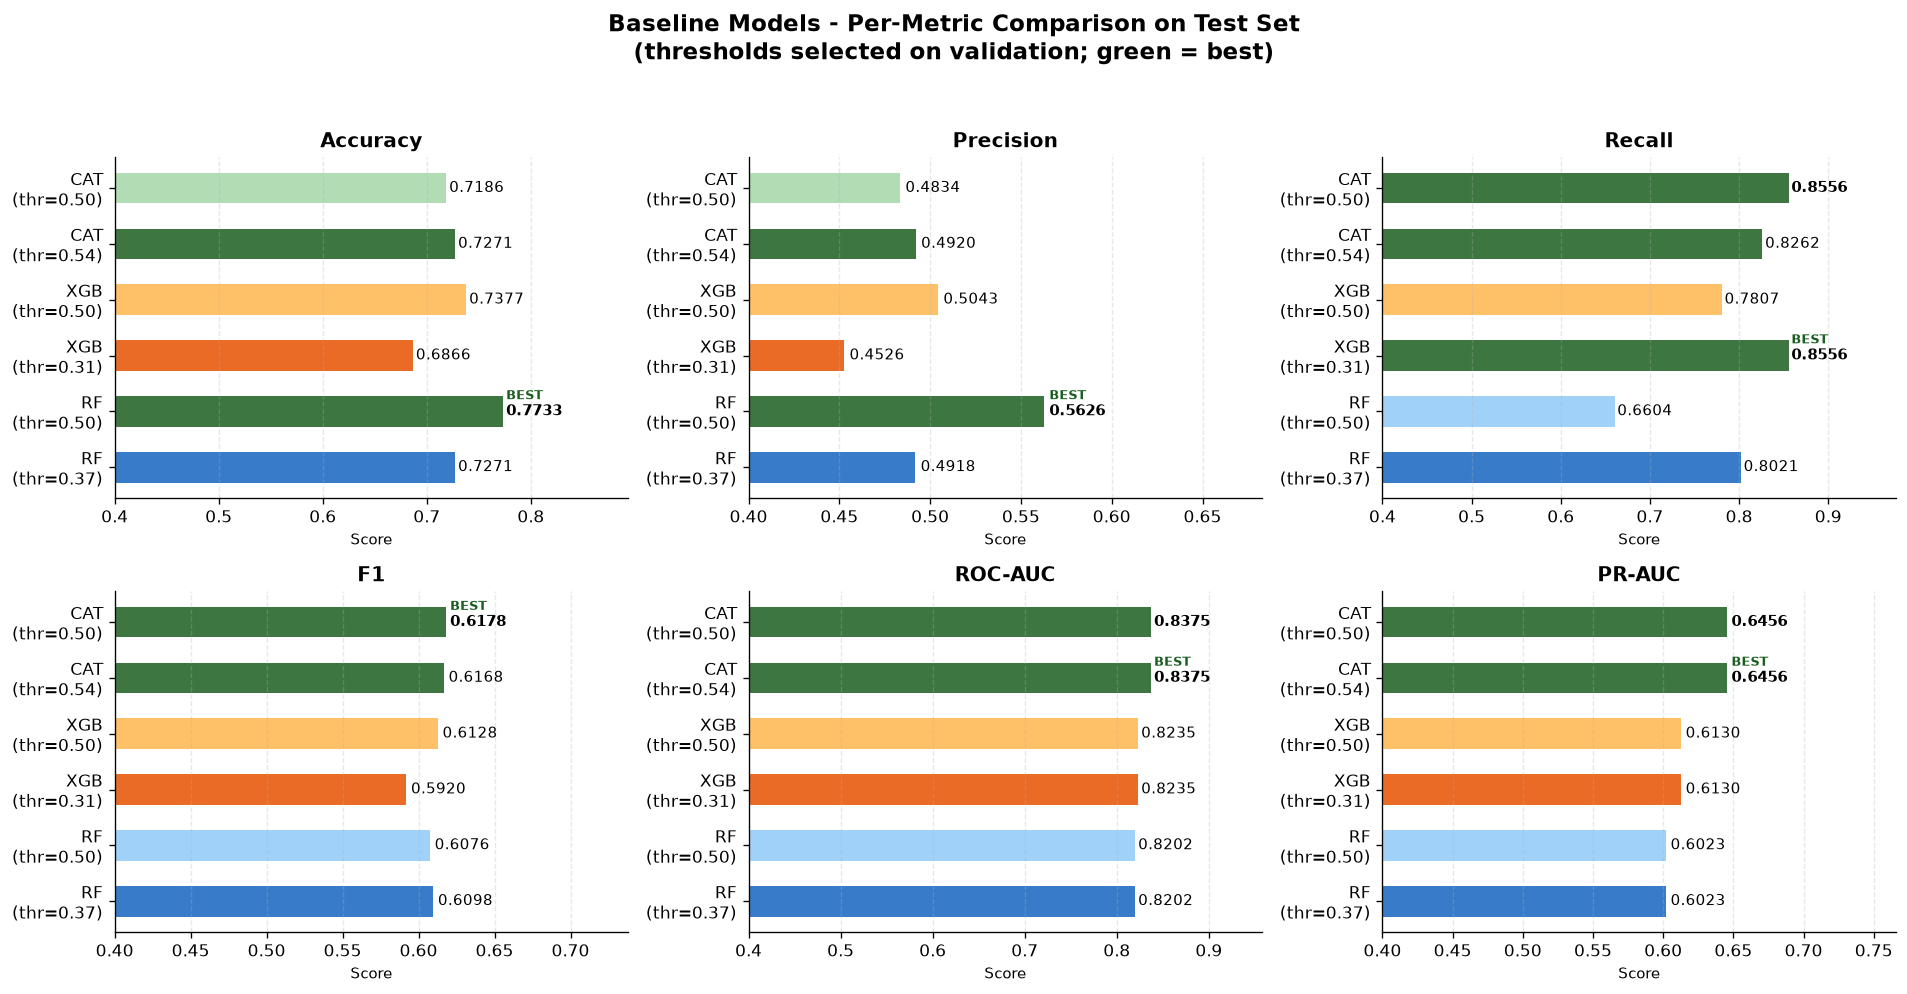

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, metric in enumerate(display_cols):
    ax     = axes[i]
    values = metrics_df[metric].values
    best   = values.max()
    bar_c  = ['#1B5E20' if v == best else c for v, c in zip(values, colours)]

    bars = ax.barh(short_labels, values, color=bar_c, alpha=0.85, height=0.55)

    for bar, val in zip(bars, values):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9,
                fontweight='bold' if val == best else 'normal')

    best_idx = values.argmax()
    ax.text(values[best_idx] + 0.003, best_idx + 0.28,
            'BEST', va='center', fontsize=8, color='#1B5E20', fontweight='bold')

    ax.set_xlim(0.4, max(values) + 0.12)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlabel('Score', fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Baseline Models - Per-Metric Comparison on Test Set\n'
             '(thresholds selected on validation; green = best)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
# plt.savefig('plots/01_baseline_per_metric.png', bbox_inches='tight', dpi=150)
plt.show()

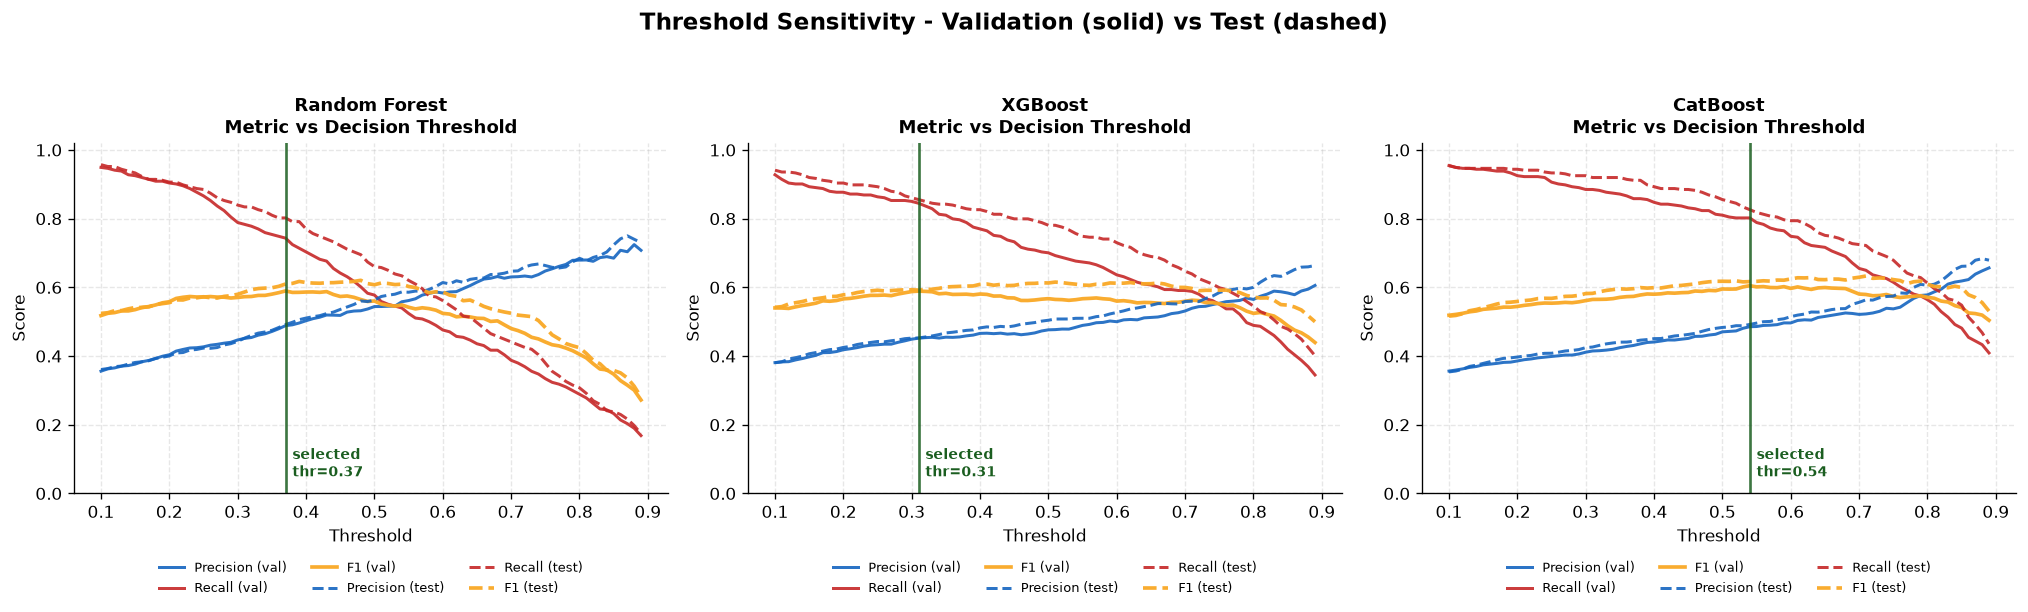

In [14]:
# Threshold sweep: how Precision / Recall / F1 move as the cut-off changes.
# Validation curve (solid) is what the threshold is chosen from; test curve
# (dashed) shows how well that choice transfers. This replaces the previous
# hard-coded discrete-threshold bar chart.
sweep = np.arange(0.10, 0.90, 0.01)

sweep_models = {
    'Random Forest': (rf_val_prob,  rf_prob_test,  thr_rf_base),
    'XGBoost':       (xgb_val_prob, xgb_prob_test, thr_xgb_base),
    'CatBoost':      (cat_val_prob, cat_prob_test, thr_cat_base),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, (vprob, tprob, chosen_thr)) in zip(axes, sweep_models.items()):
    for prob, y_true, ls, tag in [(vprob, y_val,  '-',  'val'),
                                  (tprob, y_test, '--', 'test')]:
        prec = [precision_score(y_true, (prob >= t).astype(int), zero_division=0) for t in sweep]
        rec  = [recall_score(y_true,    (prob >= t).astype(int), zero_division=0) for t in sweep]
        f1s  = [f1_score(y_true,        (prob >= t).astype(int), zero_division=0) for t in sweep]
        ax.plot(sweep, prec, ls, color='#1565C0', lw=1.8, alpha=0.9, label=f'Precision ({tag})')
        ax.plot(sweep, rec,  ls, color='#C62828', lw=1.8, alpha=0.9, label=f'Recall ({tag})')
        ax.plot(sweep, f1s,  ls, color='#F9A825', lw=2.2, alpha=0.95, label=f'F1 ({tag})')

    ax.axvline(chosen_thr, color='#1B5E20', lw=1.6, alpha=0.85)
    ax.text(chosen_thr + 0.01, 0.05, f'selected\nthr={chosen_thr:.2f}',
            fontsize=8.5, color='#1B5E20', fontweight='bold')

    ax.set_title(f'{name}\nMetric vs Decision Threshold', fontweight='bold', fontsize=11)
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=7.5, ncol=3, loc='upper center',
              bbox_to_anchor=(0.5, -0.16), frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Threshold Sensitivity - Validation (solid) vs Test (dashed)',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
# plt.savefig('plots/02_baseline_threshold_sweep.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Hyperparameter Tuning with Optuna

**Optuna** — a state-of-the-art Bayesian optimisation framework — to search each model's hyperparameter space efficiently. The objective is to **maximise 5-fold stratified CV F1-score on the training data** (not the test set, to avoid leakage).

Hyperparameters are searched with **5-fold stratified CV on the training set only**,
with SMOTE applied inside each fold so no synthetic minority samples derived from a
fold's held-out portion ever leak into its training portion.

The dedicated validation set is deliberately **not** used for hyperparameter search —
it is reserved solely for threshold selection. This keeps the two decisions independent
and leaves the test set untouched by either.

> Inner-fold variables are named `X_fold_tr` / `X_fold_va` rather than `X_val` so they
> cannot shadow the real validation set.

### 5.1 Random Forest — Optuna Tuning

In [16]:
from imblearn.over_sampling import SMOTE  
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

CV_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def rf_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 800, step=100),
        'max_depth'         : trial.suggest_int('max_depth', 3, 25),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'      : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight'      : 'balanced',
        'random_state'      : RANDOM_STATE,
        'n_jobs'            : -1,
    }

    f1_scores = []
    for tr_idx, va_idx in CV_inner.split(X_train_raw, y_train_raw):
        X_fold_tr, y_fold_tr = X_train_raw.iloc[tr_idx], y_train_raw.iloc[tr_idx]
        X_fold_va, y_fold_va = X_train_raw.iloc[va_idx], y_train_raw.iloc[va_idx]

        # SMOTE fitted inside the fold - never on the held-out portion
        sm = SMOTE(random_state=RANDOM_STATE)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_fold_tr, y_fold_tr)

        model = RandomForestClassifier(**params)
        model.fit(X_tr_sm, y_tr_sm)

        y_prob = model.predict_proba(X_fold_va)[:, 1]
        f1_scores.append(f1_score(y_fold_va, (y_prob >= 0.5).astype(int), zero_division=0))

    return float(np.mean(f1_scores))


print("Tuning Random Forest with Optuna (50 trials)...")
rf_study = optuna.create_study(direction='maximize',
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=True)

print(f"\nRF best CV F1 = {rf_study.best_value:.4f}")
print("Best params:", rf_study.best_params)

Tuning Random Forest with Optuna (50 trials)...


Best trial: 49. Best value: 0.632029: 100%|██████████| 50/50 [01:18<00:00,  1.58s/it]


RF best CV F1 = 0.6320
Best params: {'n_estimators': 200, 'max_depth': 19, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'log2'}


In [17]:
# Refit on the full SMOTE-balanced training set with the tuned hyperparameters
rf_best = RandomForestClassifier(
    **rf_study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_best.fit(X_train_smote, y_train_smote)

thr_rf_tuned, _, rf_val_prob_tuned, rf_prob = fit_select_evaluate(
    'Random Forest', rf_best,
    results_store=all_results, probs_store=all_probs,
    val_probs_store=val_probs, thr_store=thresholds_used)

Random Forest
  Validation-optimal threshold : 0.39  (val F1 = 0.6069)
              precision    recall  f1-score   support

    No Churn     0.9404    0.6563    0.7731      1033
       Churn     0.4825    0.8850    0.6245       374

    accuracy                         0.7171      1407
   macro avg     0.7114    0.7707    0.6988      1407
weighted avg     0.8187    0.7171    0.7336      1407



In [18]:
# Reference: same tuned model at the default 0.50 cut-off
print("Tuned RF at fixed threshold 0.50:")
print(classification_report(y_test, (rf_prob >= 0.50).astype(int),
                            target_names=['No Churn', 'Churn'], digits=4))

Tuned RF at fixed threshold 0.50:
              precision    recall  f1-score   support

    No Churn     0.9051    0.7754    0.8352      1033
       Churn     0.5556    0.7754    0.6473       374

    accuracy                         0.7754      1407
   macro avg     0.7303    0.7754    0.7413      1407
weighted avg     0.8122    0.7754    0.7853      1407



In [19]:
# Shared colour scheme for the baseline-vs-tuned comparison figures
C_BASE   = '#1565C0'   # blue  - baseline
C_TUNE   = '#047857'   # green - tuned
C_BASE_L = '#DBEAFE'
C_TUNE_L = '#D1FAE5'
C_DARK   = '#1C1C1E'
C_GRAY   = '#64748B'

plt.rcParams.update({
    'figure.dpi'     : 140,
    'axes.titlesize' : 12,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family'    : 'sans-serif',
})

metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']


def build_comparison(base_key, tuned_key, base_thr, tuned_thr):
    """Baseline vs tuned comparison table with dynamically labelled columns."""
    base_metrics = baseline_all_results[base_key]
    tune_metrics = all_results[tuned_key]
    b_lbl = f'Baseline (thr={base_thr:.2f})'
    t_lbl = f'Tuned (thr={tuned_thr:.2f})'
    comp = pd.DataFrame({
        b_lbl: {k: base_metrics[k] for k in metrics_cols},
        t_lbl: {k: tune_metrics[k] for k in metrics_cols},
    })
    comp['Improvement'] = comp[t_lbl] - comp[b_lbl]
    return comp, b_lbl, t_lbl


def plot_baseline_vs_tuned(comp, b_lbl, t_lbl, title, outfile):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    x, width = np.arange(len(metrics_cols)), 0.32

    bars_b = axes[0].bar(x - width/2, comp[b_lbl], width,
                         color=C_BASE, alpha=0.85, label=b_lbl)
    bars_t = axes[0].bar(x + width/2, comp[t_lbl], width,
                         color=C_TUNE, alpha=0.85, label=t_lbl)

    for bars, col in [(bars_b, C_BASE), (bars_t, C_TUNE)]:
        for bar in bars:
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                         f'{bar.get_height():.4f}', ha='center', va='bottom',
                         fontsize=8.5, color=col, fontweight='bold')

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics_cols, fontsize=10)
    axes[0].set_ylim(0.45, 1.02)
    axes[0].set_ylabel('Score')
    axes[0].set_title('All Metrics - Baseline vs Tuned', fontweight='bold')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    deltas = comp['Improvement']
    colours_delta = [C_TUNE if v >= 0 else '#DC2626' for v in deltas]
    axes[1].bar(metrics_cols, deltas, color=colours_delta, alpha=0.85, width=0.5)
    axes[1].axhline(0, color=C_DARK, linewidth=1)

    for i, val in enumerate(deltas.values):
        axes[1].text(i, val + (0.0008 if val >= 0 else -0.0018), f'{val:+.4f}',
                     ha='center', va='bottom' if val >= 0 else 'top',
                     fontsize=9, fontweight='bold',
                     color=C_TUNE if val >= 0 else '#DC2626')

    axes[1].set_ylabel('Improvement (Tuned - Baseline)')
    axes[1].set_title('Metric Improvement from Tuning', fontweight='bold')
    axes[1].set_xticks(np.arange(len(metrics_cols)))
    axes[1].set_xticklabels(metrics_cols, fontsize=10)
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(outfile, bbox_inches='tight', dpi=150)
    plt.show()


def plot_roc_pr(base_prob, tuned_prob, base_metrics, tune_metrics,
                base_thr, tuned_thr, title, outfile):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

    fpr_b, tpr_b, _ = roc_curve(y_test, base_prob)
    fpr_t, tpr_t, _ = roc_curve(y_test, tuned_prob)

    axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='No Skill (AUC=0.50)')
    axes[0].plot(fpr_b, tpr_b, color=C_BASE, lw=2.5,
                 label=f"Baseline  (AUC={base_metrics['ROC-AUC']:.4f})")
    axes[0].plot(fpr_t, tpr_t, color=C_TUNE, lw=2.5,
                 label=f"Tuned     (AUC={tune_metrics['ROC-AUC']:.4f})")
    axes[0].fill_between(fpr_b, tpr_b, alpha=0.08, color=C_BASE)
    axes[0].fill_between(fpr_t, tpr_t, alpha=0.08, color=C_TUNE)
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate (Recall)')
    axes[0].set_title('ROC Curves - Baseline vs Tuned', fontweight='bold')
    axes[0].legend(loc='lower right')
    axes[0].grid(alpha=0.25)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    prec_b, rec_b, _ = precision_recall_curve(y_test, base_prob)
    prec_t, rec_t, _ = precision_recall_curve(y_test, tuned_prob)
    no_skill = y_test.mean()

    axes[1].axhline(no_skill, color='grey', lw=1, linestyle='--',
                    label=f'No Skill (P={no_skill:.3f})')
    axes[1].plot(rec_b, prec_b, color=C_BASE, lw=2.5,
                 label=f"Baseline  (PR-AUC={base_metrics['PR-AUC']:.4f})")
    axes[1].plot(rec_t, prec_t, color=C_TUNE, lw=2.5,
                 label=f"Tuned     (PR-AUC={tune_metrics['PR-AUC']:.4f})")
    axes[1].fill_between(rec_b, prec_b, alpha=0.08, color=C_BASE)
    axes[1].fill_between(rec_t, prec_t, alpha=0.08, color=C_TUNE)

    for prob, thr, col, lbl in [
        (base_prob,  base_thr,  C_BASE, f'Baseline thr={base_thr:.2f}'),
        (tuned_prob, tuned_thr, C_TUNE, f'Tuned thr={tuned_thr:.2f}'),
    ]:
        p = precision_score(y_test, (prob >= thr).astype(int), zero_division=0)
        r = recall_score(y_test, (prob >= thr).astype(int), zero_division=0)
        axes[1].scatter(r, p, s=120, color=col, zorder=5, edgecolors='white', lw=2)
        axes[1].annotate(lbl, (r, p), xytext=(6, 4), textcoords='offset points',
                         fontsize=8.5, color=col)

    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curves - Baseline vs Tuned', fontweight='bold')
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.25)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(outfile, bbox_inches='tight', dpi=150)
    plt.show()

print("Comparison helpers defined.")

Comparison helpers defined.


In [20]:
comp_rf, b_lbl_rf, t_lbl_rf = build_comparison(
    'RF Baseline (val-opt thr)', 'Random Forest', thr_rf_base, thr_rf_tuned)

print("=" * 62)
print("RANDOM FOREST - BASELINE vs TUNED (test set)")
print("=" * 62)
print(comp_rf.round(4).to_string())
print()
print("Baseline params : n_estimators=300, max_depth=None (sklearn default)")
print("Tuned params    :", rf_study.best_params)
print("Tuning method   : Optuna TPE, 50 trials, 5-fold CV F1 on training set")
print(f"Best CV F1      : {rf_study.best_value:.4f}")
print(f"Thresholds      : baseline={thr_rf_base:.2f}, tuned={thr_rf_tuned:.2f} "
      f"(both selected on validation)")

RANDOM FOREST - BASELINE vs TUNED (test set)
           Baseline (thr=0.37)  Tuned (thr=0.39)  Improvement
Accuracy                0.7271            0.7171      -0.0100
Precision               0.4918            0.4825      -0.0093
Recall                  0.8021            0.8850       0.0829
F1                      0.6098            0.6245       0.0148
ROC-AUC                 0.8202            0.8468       0.0266
PR-AUC                  0.6023            0.6422       0.0399

Baseline params : n_estimators=300, max_depth=None (sklearn default)
Tuned params    : {'n_estimators': 200, 'max_depth': 19, 'min_samples_split': 11, 'min_samples_leaf': 9, 'max_features': 'log2'}
Tuning method   : Optuna TPE, 50 trials, 5-fold CV F1 on training set
Best CV F1      : 0.6320
Thresholds      : baseline=0.37, tuned=0.39 (both selected on validation)


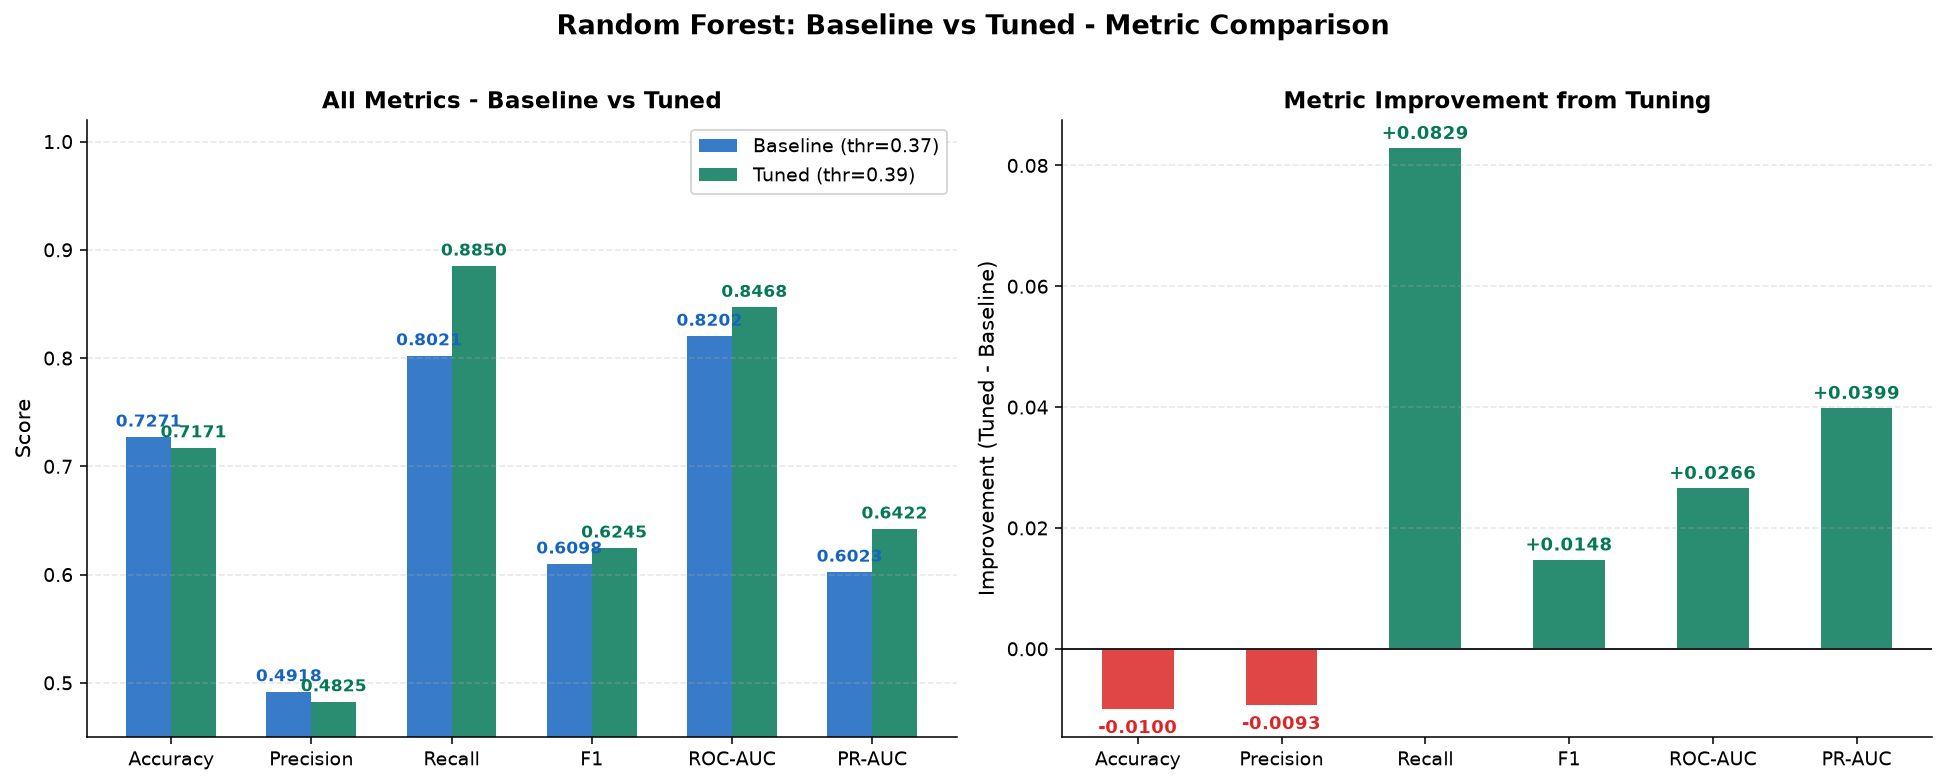

In [21]:
plot_baseline_vs_tuned(comp_rf, b_lbl_rf, t_lbl_rf,
                       'Random Forest: Baseline vs Tuned - Metric Comparison',
                       'plots/03_rf_metrics_comparison.png')

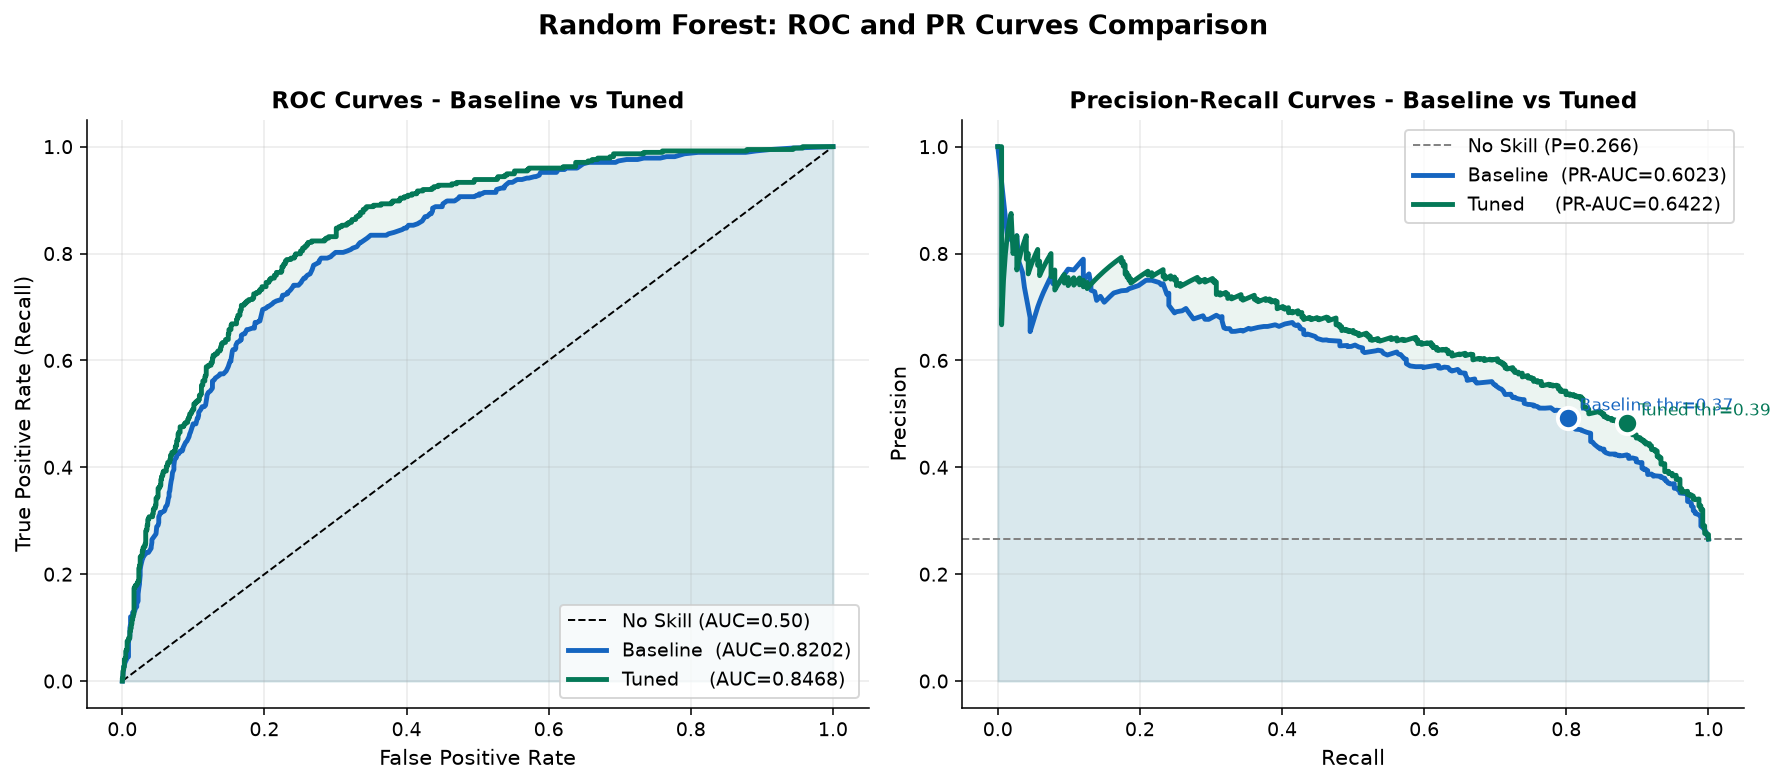

In [22]:
plot_roc_pr(rf_prob_test, rf_prob,
            baseline_all_results['RF Baseline (val-opt thr)'], all_results['Random Forest'],
            thr_rf_base, thr_rf_tuned,
            'Random Forest: ROC and PR Curves Comparison',
            'plots/04_rf_roc_pr_curves.png')

### 5.2 XGBoost — Optuna Tuning

In [23]:
CV_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def xgb_objective(trial):
    params = {
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 7),
        'subsample'        : trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'min_child_weight' : trial.suggest_int('min_child_weight', 5, 30),
        'gamma'            : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'scale_pos_weight' : trial.suggest_float('scale_pos_weight', 1.0, 4.0),
        'eval_metric'      : 'aucpr',
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbosity'        : 0,
    }

    f1_scores, best_iters = [], []
    for tr_idx, va_idx in CV_inner.split(X_train_raw, y_train_raw):
        X_fold_tr, y_fold_tr = X_train_raw.iloc[tr_idx], y_train_raw.iloc[tr_idx]
        X_fold_va, y_fold_va = X_train_raw.iloc[va_idx], y_train_raw.iloc[va_idx]

        sm = SMOTE(random_state=RANDOM_STATE)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_fold_tr, y_fold_tr)

        model = XGBClassifier(**params, n_estimators=1000, early_stopping_rounds=40)
        model.fit(X_tr_sm, y_tr_sm, eval_set=[(X_fold_va, y_fold_va)], verbose=False)
        best_iters.append(model.best_iteration)

        y_prob = model.predict_proba(X_fold_va)[:, 1]
        f1_scores.append(f1_score(y_fold_va, (y_prob >= 0.5).astype(int), zero_division=0))

    # Record the average stopping point so the final refit can reuse it
    trial.set_user_attr('mean_best_iteration', int(np.mean(best_iters)))
    return float(np.mean(f1_scores))


print("Tuning XGBoost (100 trials)...")
xgb_study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f"\nXGB best CV F1 = {xgb_study.best_value:.4f}")
print("Best params:", xgb_study.best_params)
print("Mean best iteration across folds:",
      xgb_study.best_trial.user_attrs.get('mean_best_iteration'))

Tuning XGBoost (100 trials)...


Best trial: 97. Best value: 0.62945: 100%|██████████| 100/100 [02:22<00:00,  1.43s/it]


XGB best CV F1 = 0.6295
Best params: {'learning_rate': 0.10807035644380665, 'max_depth': 3, 'subsample': 0.6290547578226616, 'colsample_bytree': 0.626373281906496, 'min_child_weight': 21, 'gamma': 4.635104395017581, 'reg_alpha': 0.0417244127775171, 'reg_lambda': 1.100790469955541, 'scale_pos_weight': 1.0434571133643489}
Mean best iteration across folds: 56


In [24]:
# Refit using the CV-derived number of rounds rather than early-stopping on a
# fresh split - this avoids consuming the validation set, which is reserved for
# threshold selection.
n_rounds_xgb = xgb_study.best_trial.user_attrs.get('mean_best_iteration', 500)
n_rounds_xgb = max(int(n_rounds_xgb), 50)

xgb_best = XGBClassifier(
    **xgb_study.best_params,
    n_estimators = n_rounds_xgb,
    eval_metric  = 'aucpr',
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    verbosity    = 0,
)
xgb_best.fit(X_train_smote, y_train_smote)
print(f"Refitted XGBoost with n_estimators={n_rounds_xgb} (from CV early stopping)\n")

thr_xgb_tuned, _, xgb_val_prob_tuned, xgb_prob = fit_select_evaluate(
    'XGBoost', xgb_best,
    results_store=all_results, probs_store=all_probs,
    val_probs_store=val_probs, thr_store=thresholds_used)

Refitted XGBoost with n_estimators=56 (from CV early stopping)

XGBoost
  Validation-optimal threshold : 0.45  (val F1 = 0.6201)
              precision    recall  f1-score   support

    No Churn     0.9333    0.6912    0.7942      1033
       Churn     0.5031    0.8636    0.6358       374

    accuracy                         0.7370      1407
   macro avg     0.7182    0.7774    0.7150      1407
weighted avg     0.8190    0.7370    0.7521      1407



In [25]:
print("Tuned XGBoost at fixed threshold 0.50:")
print(classification_report(y_test, (xgb_prob >= 0.50).astype(int),
                            target_names=['No Churn', 'Churn'], digits=4))

Tuned XGBoost at fixed threshold 0.50:
              precision    recall  f1-score   support

    No Churn     0.9239    0.7289    0.8149      1033
       Churn     0.5270    0.8342    0.6460       374

    accuracy                         0.7569      1407
   macro avg     0.7255    0.7816    0.7304      1407
weighted avg     0.8184    0.7569    0.7700      1407



In [26]:
comp_xgb, b_lbl_xgb, t_lbl_xgb = build_comparison(
    'XGB Baseline (val-opt thr)', 'XGBoost', thr_xgb_base, thr_xgb_tuned)

print("=" * 62)
print("XGBOOST - BASELINE vs TUNED (test set)")
print("=" * 62)
print(comp_xgb.round(4).to_string())
print()
print("Baseline params : n_estimators=500, max_depth=6, learning_rate=0.05, "
      "subsample=0.8, colsample_bytree=0.8")
print("Tuned params    :", xgb_study.best_params)
print(f"Tuned rounds    : {n_rounds_xgb}")
print("Tuning method   : Optuna TPE, 100 trials, 5-fold CV F1 on training set")
print(f"Best CV F1      : {xgb_study.best_value:.4f}")
print(f"Thresholds      : baseline={thr_xgb_base:.2f}, tuned={thr_xgb_tuned:.2f} "
      f"(both selected on validation)")

XGBOOST - BASELINE vs TUNED (test set)
           Baseline (thr=0.31)  Tuned (thr=0.45)  Improvement
Accuracy                0.6866            0.7370       0.0505
Precision               0.4526            0.5031       0.0505
Recall                  0.8556            0.8636       0.0080
F1                      0.5920            0.6358       0.0438
ROC-AUC                 0.8235            0.8522       0.0287
PR-AUC                  0.6130            0.6515       0.0385

Baseline params : n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8
Tuned params    : {'learning_rate': 0.10807035644380665, 'max_depth': 3, 'subsample': 0.6290547578226616, 'colsample_bytree': 0.626373281906496, 'min_child_weight': 21, 'gamma': 4.635104395017581, 'reg_alpha': 0.0417244127775171, 'reg_lambda': 1.100790469955541, 'scale_pos_weight': 1.0434571133643489}
Tuned rounds    : 56
Tuning method   : Optuna TPE, 100 trials, 5-fold CV F1 on training set
Best CV F1      : 0.6295
T

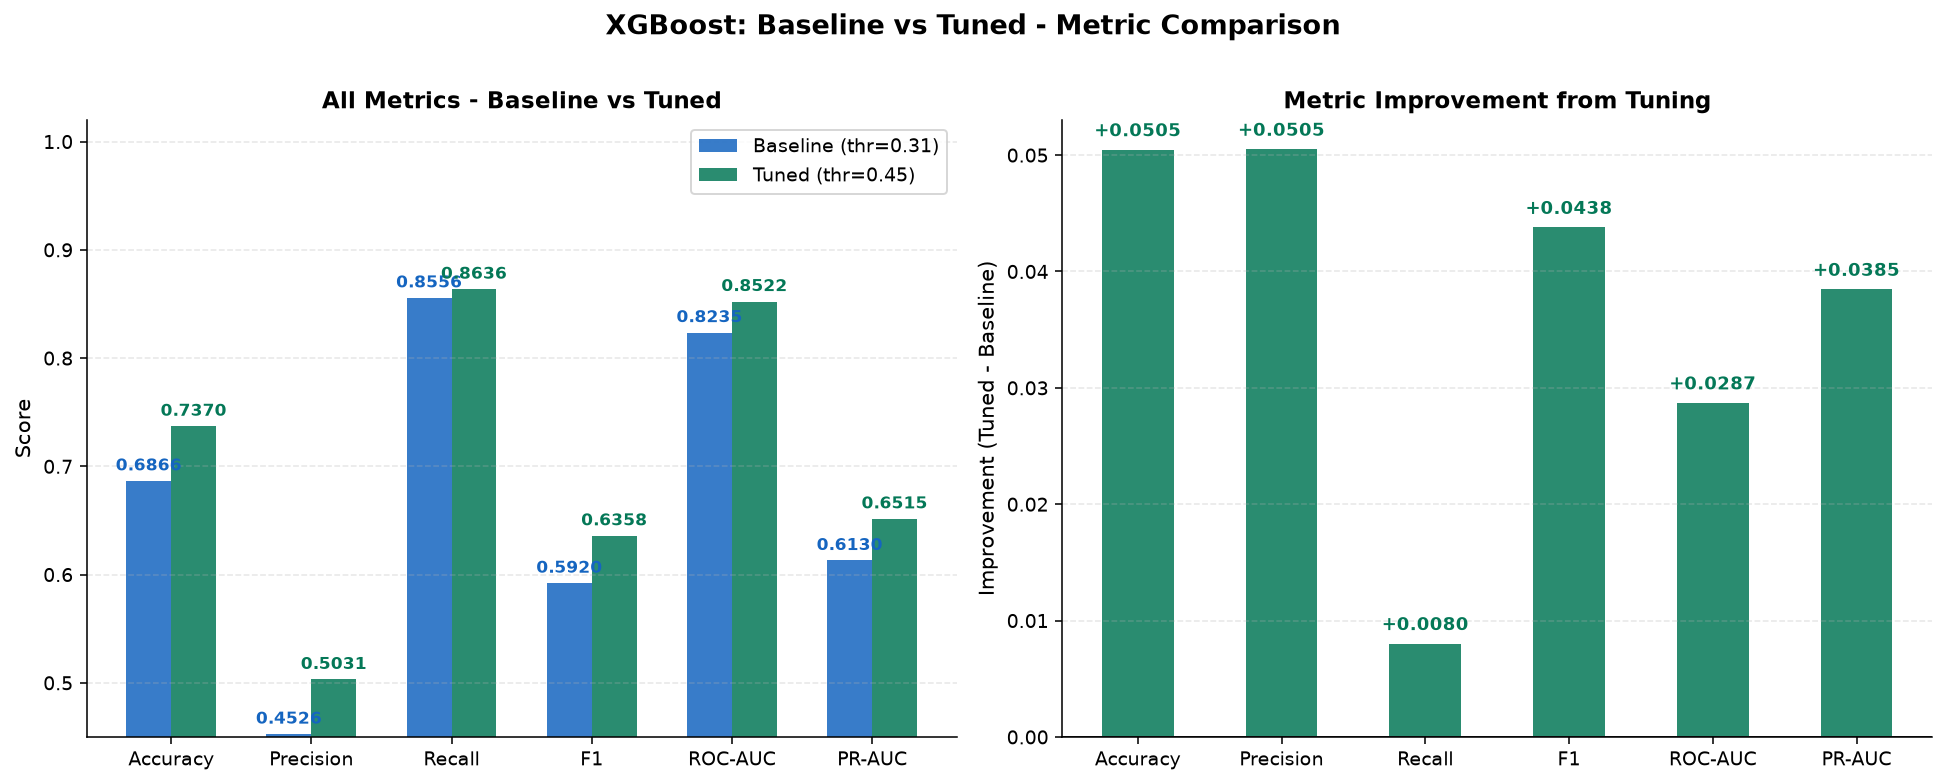

In [27]:
plot_baseline_vs_tuned(comp_xgb, b_lbl_xgb, t_lbl_xgb,
                       'XGBoost: Baseline vs Tuned - Metric Comparison',
                       'plots/05_xgb_metrics_comparison.png')

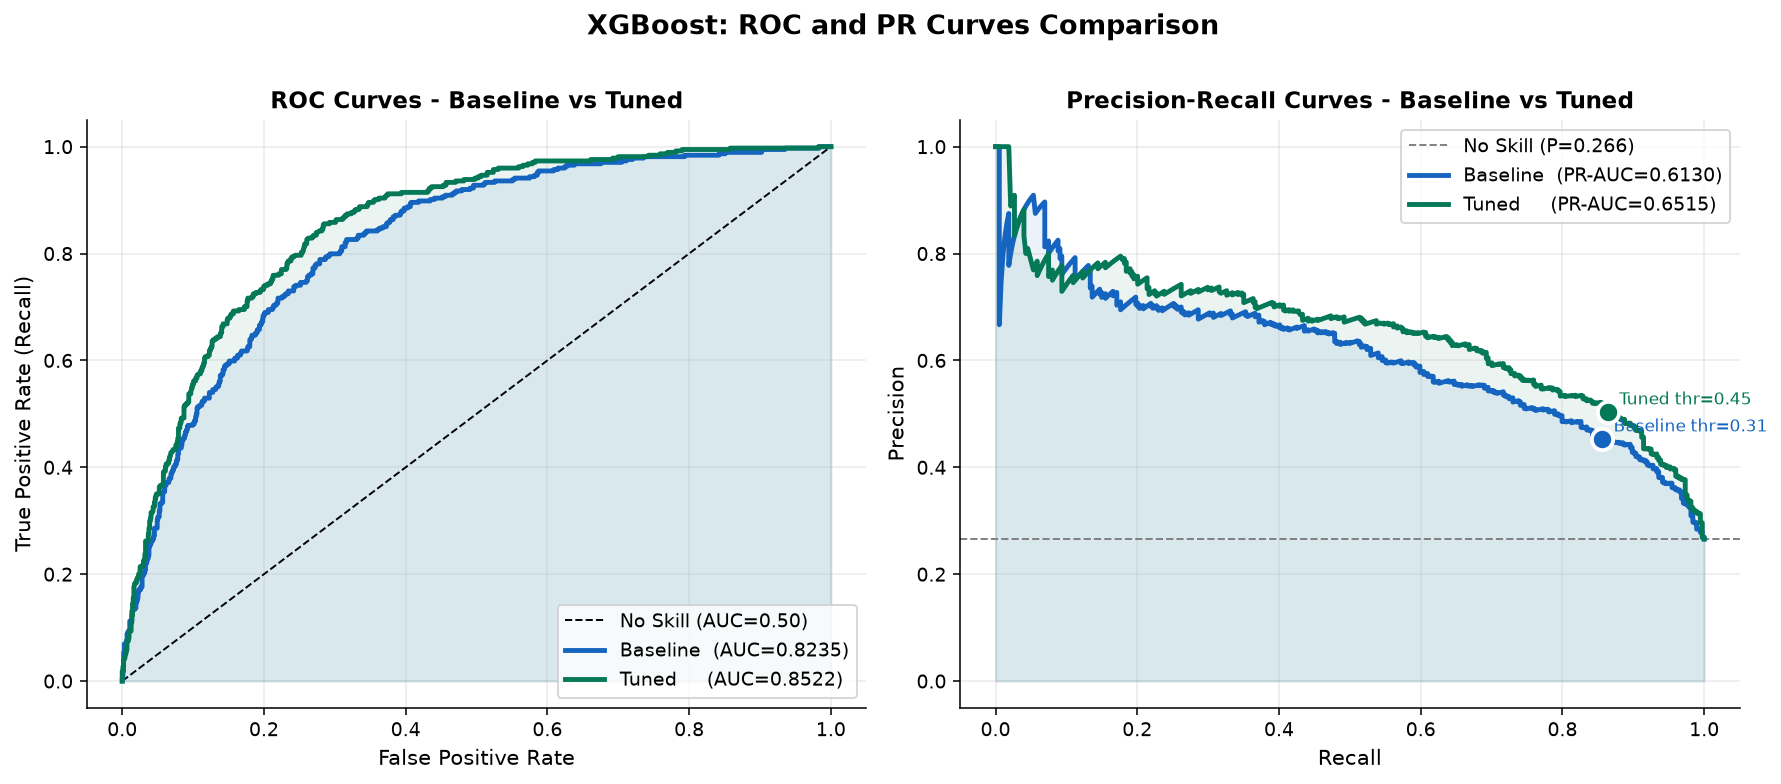

In [28]:
plot_roc_pr(xgb_prob_test, xgb_prob,
            baseline_all_results['XGB Baseline (val-opt thr)'], all_results['XGBoost'],
            thr_xgb_base, thr_xgb_tuned,
            'XGBoost: ROC and PR Curves Comparison',
            'plots/06_xgb_roc_pr_curves.png')

### 5.3 CatBoost — Optuna Tuning

In [29]:
def cat_objective(trial):
    minority_weight = trial.suggest_float('minority_weight', 1.0, 4.0)

    params = {
        'iterations'          : 1000,
        'learning_rate'       : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth'               : trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg'         : trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
        'bagging_temperature' : trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength'     : trial.suggest_float('random_strength', 0.1, 2.0),
        'border_count'        : trial.suggest_int('border_count', 32, 128),
        'class_weights'       : [1.0, minority_weight],
        'eval_metric'         : 'F1',
        'od_type'             : 'Iter',
        'od_wait'             : 40,
        'loss_function'       : 'Logloss',
        'random_state'        : RANDOM_STATE,
        'verbose'             : False,
        'allow_writing_files' : False,
    }

    f1_scores, best_iters = [], []
    for tr_idx, va_idx in CV_inner.split(X_train_raw, y_train_raw):
        X_fold_tr, y_fold_tr = X_train_raw.iloc[tr_idx], y_train_raw.iloc[tr_idx]
        X_fold_va, y_fold_va = X_train_raw.iloc[va_idx], y_train_raw.iloc[va_idx]

        sm = SMOTE(random_state=RANDOM_STATE)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_fold_tr, y_fold_tr)

        model = CatBoostClassifier(**params)
        model.fit(X_tr_sm, y_tr_sm, eval_set=(X_fold_va, y_fold_va),
                  use_best_model=True, verbose=False)
        best_iters.append(model.get_best_iteration())

        y_prob = model.predict_proba(X_fold_va)[:, 1]
        f1_scores.append(f1_score(y_fold_va, (y_prob >= 0.5).astype(int), zero_division=0))

    trial.set_user_attr('mean_best_iteration', int(np.mean(best_iters)))
    return float(np.mean(f1_scores))


print("Tuning CatBoost (100 trials)...")
cat_study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
cat_study.optimize(cat_objective, n_trials=100, show_progress_bar=True)

print(f"\nCatBoost best CV F1 = {cat_study.best_value:.4f}")
print("Best params:", cat_study.best_params)
print("Mean best iteration across folds:",
      cat_study.best_trial.user_attrs.get('mean_best_iteration'))

Tuning CatBoost (100 trials)...


Best trial: 11. Best value: 0.643469: 100%|██████████| 100/100 [00:59<00:00,  1.69it/s]


CatBoost best CV F1 = 0.6435
Best params: {'minority_weight': 1.0191493103020022, 'learning_rate': 0.14165514353398773, 'depth': 8, 'l2_leaf_reg': 19.68543860888549, 'bagging_temperature': 0.243154176278787, 'random_strength': 1.2302961204637586, 'border_count': 102}
Mean best iteration across folds: 33


In [30]:
# As with XGBoost, refit for the CV-derived number of iterations instead of
# carving an early-stopping split out of the training data.
best_cat   = dict(cat_study.best_params)
minority_w = best_cat.pop('minority_weight')

n_iter_cat = cat_study.best_trial.user_attrs.get('mean_best_iteration', 500)
n_iter_cat = max(int(n_iter_cat), 50)

cat_best = CatBoostClassifier(
    iterations          = n_iter_cat,
    learning_rate       = best_cat['learning_rate'],
    depth               = best_cat['depth'],
    l2_leaf_reg         = best_cat['l2_leaf_reg'],
    bagging_temperature = best_cat['bagging_temperature'],
    random_strength     = best_cat['random_strength'],
    border_count        = best_cat['border_count'],
    class_weights       = [1.0, minority_w],
    eval_metric         = 'F1',
    loss_function       = 'Logloss',
    random_state        = RANDOM_STATE,
    verbose             = False,
    allow_writing_files = False,
)
cat_best.fit(X_train_smote, y_train_smote)
print(f"Refitted CatBoost with iterations={n_iter_cat} (from CV early stopping)\n")

thr_cat_tuned, _, cat_val_prob_tuned, cat_prob = fit_select_evaluate(
    'CatBoost', cat_best,
    results_store=all_results, probs_store=all_probs,
    val_probs_store=val_probs, thr_store=thresholds_used)

Refitted CatBoost with iterations=50 (from CV early stopping)

CatBoost
  Validation-optimal threshold : 0.44  (val F1 = 0.6010)
              precision    recall  f1-score   support

    No Churn     0.9160    0.7183    0.8052      1033
       Churn     0.5126    0.8182    0.6303       374

    accuracy                         0.7448      1407
   macro avg     0.7143    0.7682    0.7177      1407
weighted avg     0.8088    0.7448    0.7587      1407



In [31]:
print("Tuned CatBoost at fixed threshold 0.50:")
print(classification_report(y_test, (cat_prob >= 0.50).astype(int),
                            target_names=['No Churn', 'Churn'], digits=4))

Tuned CatBoost at fixed threshold 0.50:
              precision    recall  f1-score   support

    No Churn     0.9038    0.7638    0.8279      1033
       Churn     0.5431    0.7754    0.6388       374

    accuracy                         0.7669      1407
   macro avg     0.7234    0.7696    0.7333      1407
weighted avg     0.8079    0.7669    0.7776      1407



In [32]:
comp_cat, b_lbl_cat, t_lbl_cat = build_comparison(
    'CAT Baseline (val-opt thr)', 'CatBoost', thr_cat_base, thr_cat_tuned)

print("=" * 62)
print("CATBOOST - BASELINE vs TUNED (test set)")
print("=" * 62)
print(comp_cat.round(4).to_string())
print()
print("Baseline params : iterations=500, depth=6, learning_rate=0.05")
print("Tuned params    :", cat_study.best_params)
print(f"Tuned iterations: {n_iter_cat}")
print("Tuning method   : Optuna TPE, 100 trials, 5-fold CV F1 on training set")
print(f"Best CV F1      : {cat_study.best_value:.4f}")
print(f"Thresholds      : baseline={thr_cat_base:.2f}, tuned={thr_cat_tuned:.2f} "
      f"(both selected on validation)")

CATBOOST - BASELINE vs TUNED (test set)
           Baseline (thr=0.54)  Tuned (thr=0.44)  Improvement
Accuracy                0.7271            0.7448       0.0178
Precision               0.4920            0.5126       0.0205
Recall                  0.8262            0.8182      -0.0080
F1                      0.6168            0.6303       0.0135
ROC-AUC                 0.8375            0.8446       0.0072
PR-AUC                  0.6456            0.6444      -0.0012

Baseline params : iterations=500, depth=6, learning_rate=0.05
Tuned params    : {'minority_weight': 1.0191493103020022, 'learning_rate': 0.14165514353398773, 'depth': 8, 'l2_leaf_reg': 19.68543860888549, 'bagging_temperature': 0.243154176278787, 'random_strength': 1.2302961204637586, 'border_count': 102}
Tuned iterations: 50
Tuning method   : Optuna TPE, 100 trials, 5-fold CV F1 on training set
Best CV F1      : 0.6435
Thresholds      : baseline=0.54, tuned=0.44 (both selected on validation)


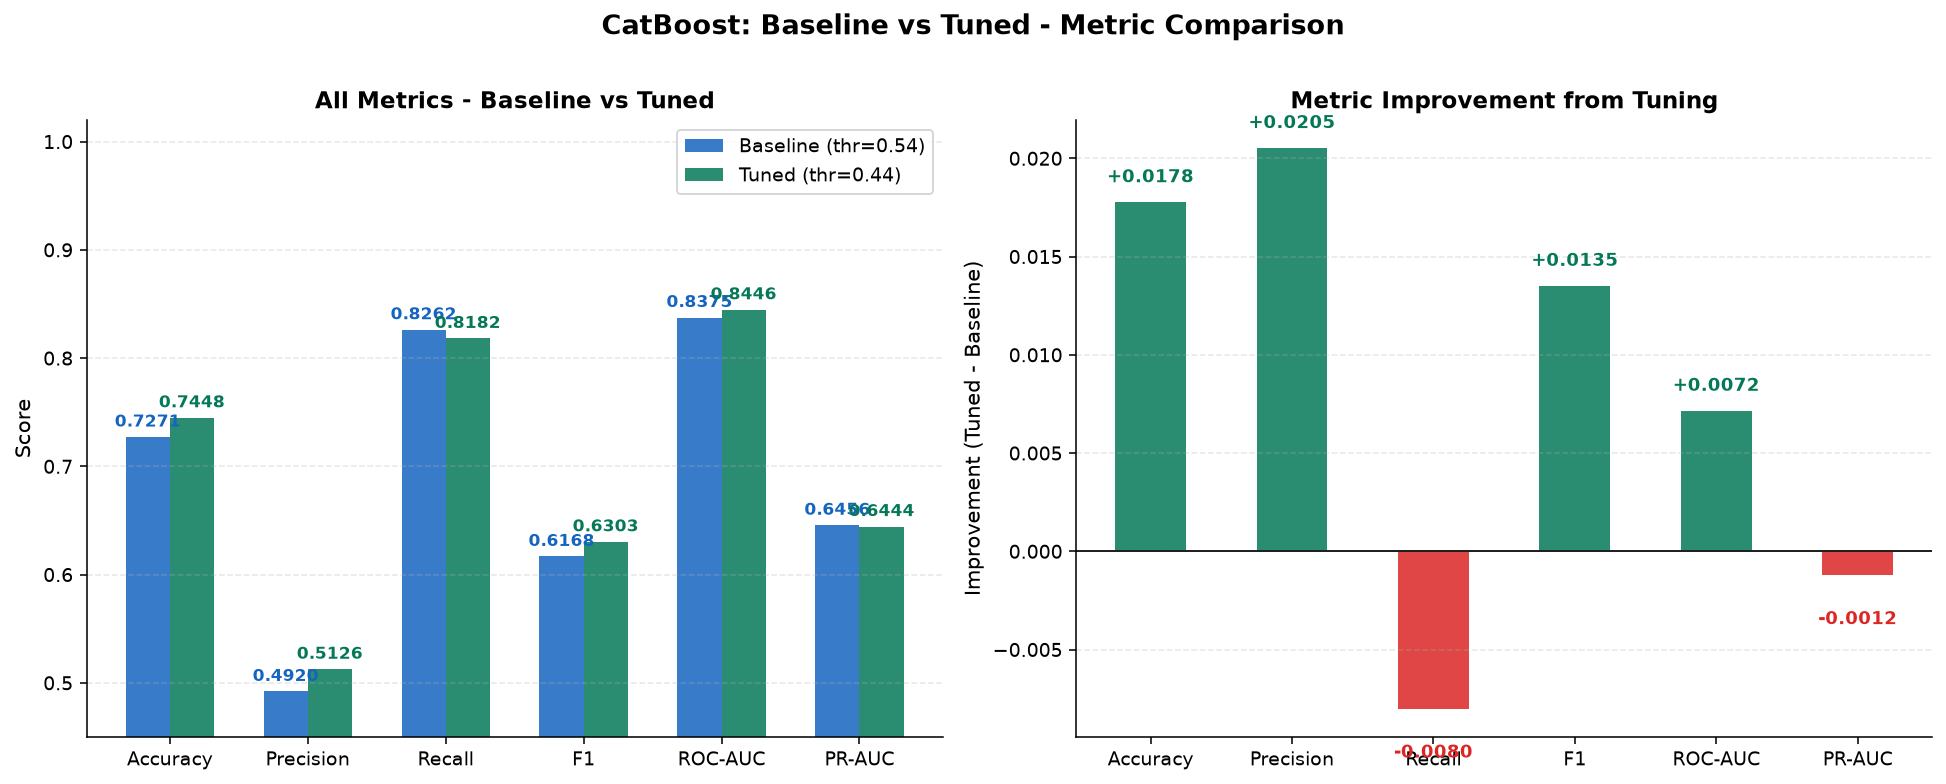

In [33]:
plot_baseline_vs_tuned(comp_cat, b_lbl_cat, t_lbl_cat,
                       'CatBoost: Baseline vs Tuned - Metric Comparison',
                       'plots/07_catboost_metrics_comparison.png')

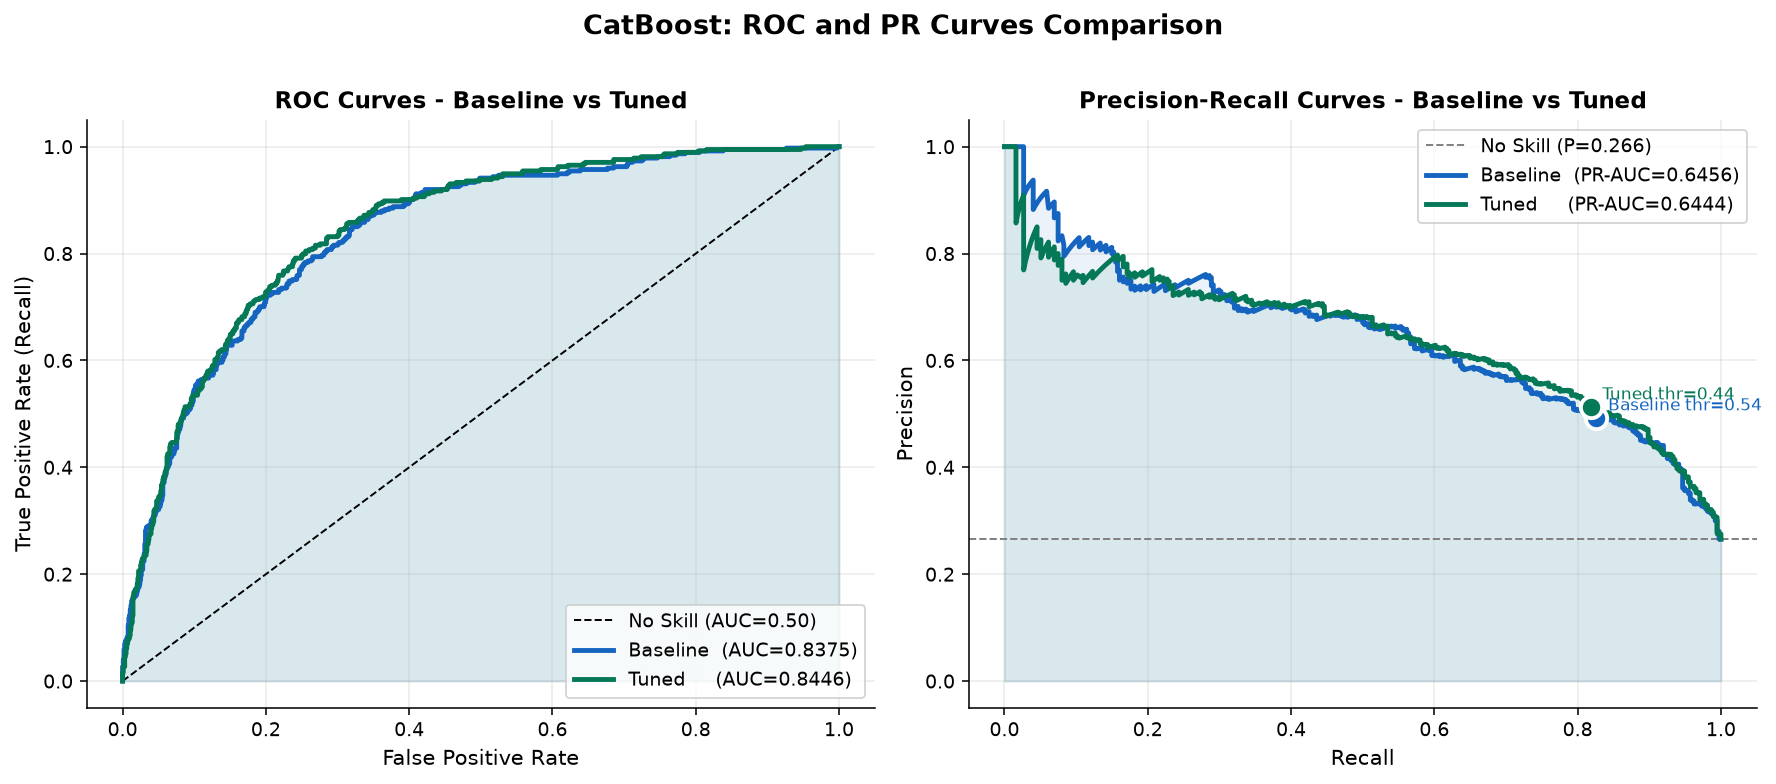

In [34]:
plot_roc_pr(cat_prob_test, cat_prob,
            baseline_all_results['CAT Baseline (val-opt thr)'], all_results['CatBoost'],
            thr_cat_base, thr_cat_tuned,
            'CatBoost: ROC and PR Curves Comparison',
            'plots/08_catboost_roc_pr_curves.png')

## 6. Model Comparison

### 6.1 Metrics Comparison Table

In [35]:
metrics_df = pd.DataFrame(all_results).T
display_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

print("\n" + "=" * 78)
print("TUNED MODELS - TEST SET PERFORMANCE")
print("Thresholds selected on validation and applied unchanged to test")
print("=" * 78)
print(metrics_df[['Threshold'] + display_cols].round(4).to_string())

print("\n-> Best per metric:")
for col in display_cols:
    best_model = metrics_df[display_cols].astype(float)[col].idxmax()
    print(f"   {col:12s}: {best_model} ({float(metrics_df.loc[best_model, col]):.4f})")


TUNED MODELS - TEST SET PERFORMANCE
Thresholds selected on validation and applied unchanged to test
              Threshold  Accuracy Precision    Recall        F1   ROC-AUC    PR-AUC
Random Forest      0.39  0.717129  0.482507  0.885027  0.624528  0.846842   0.64215
XGBoost            0.45  0.737029  0.503115  0.863636  0.635827  0.852242  0.651469
CatBoost           0.44  0.744847  0.512563  0.818182  0.630278  0.844636  0.644373

-> Best per metric:
   Accuracy    : CatBoost (0.7448)
   Precision   : CatBoost (0.5126)
   Recall      : Random Forest (0.8850)
   F1          : XGBoost (0.6358)
   ROC-AUC     : XGBoost (0.8522)
   PR-AUC      : XGBoost (0.6515)


### 6.2 Bar Chart Comparison

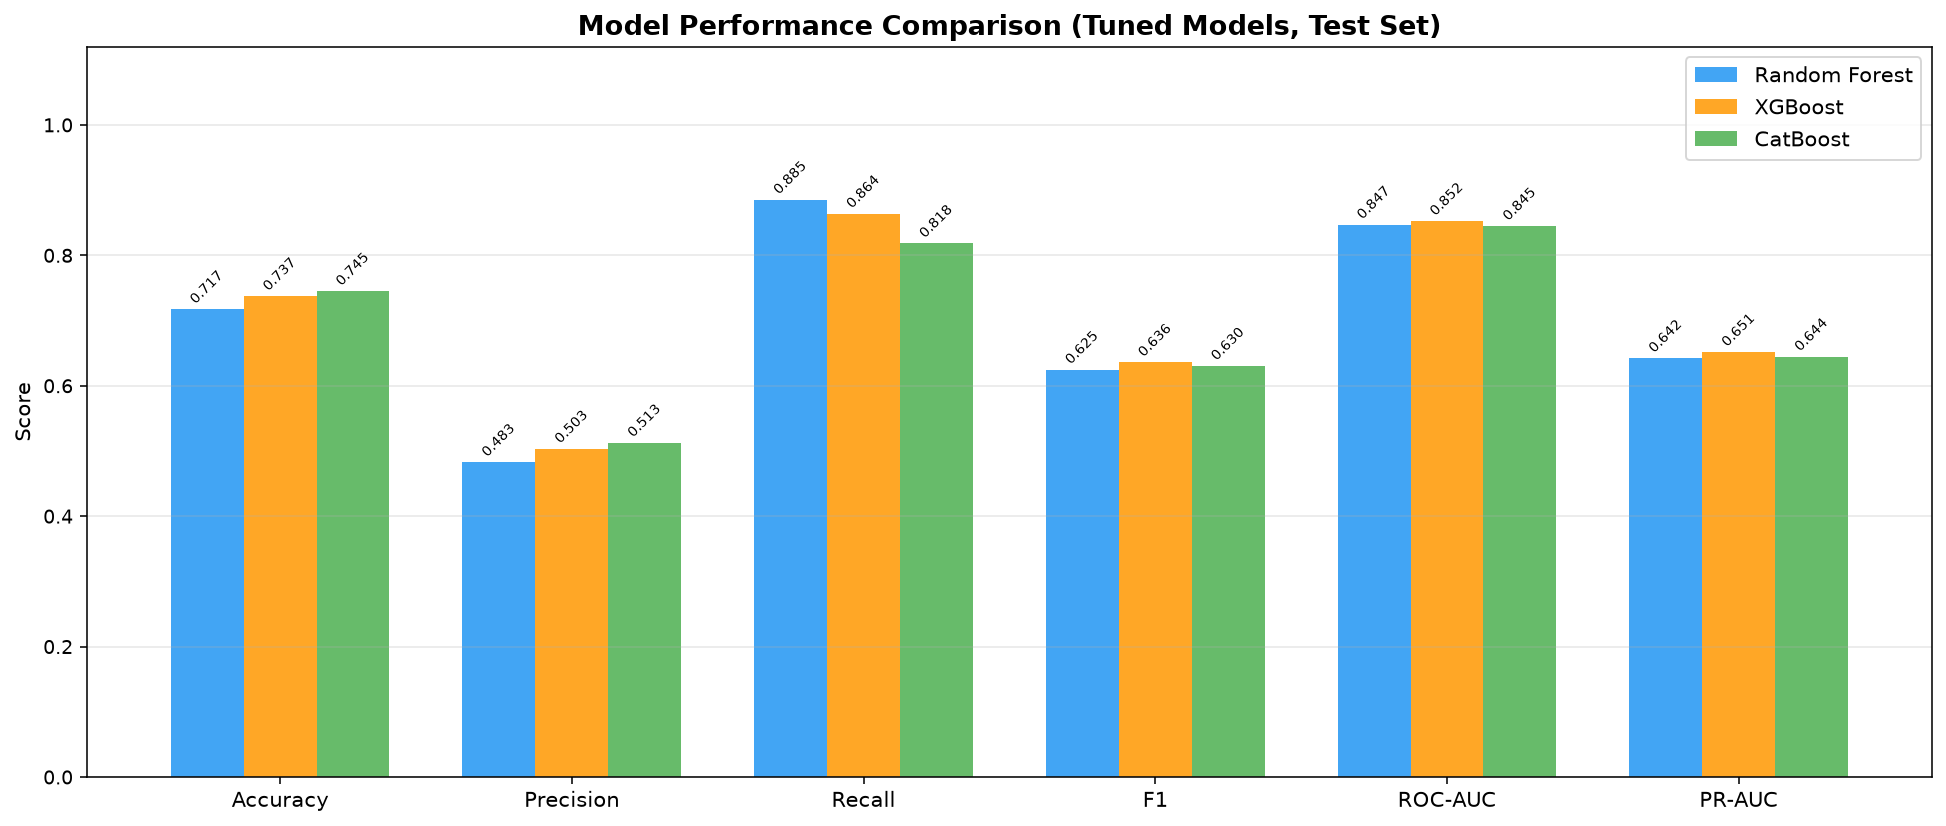

In [36]:
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
models  = list(all_results.keys())
x       = np.arange(len(metrics_plot))
width   = 0.25
colours = {'Random Forest': '#2196F3', 'XGBoost': '#FF9800', 'CatBoost': '#4CAF50'}

fig, ax = plt.subplots(figsize=(14, 6))
for i, model in enumerate(models):
    vals = [all_results[model][m] for m in metrics_plot]
    bars = ax.bar(x + i * width, vals, width, label=model,
                  color=colours[model], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Tuned Models, Test Set)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/09_model_comparison.png', bbox_inches='tight')
plt.show()

### 6.3 ROC Curves

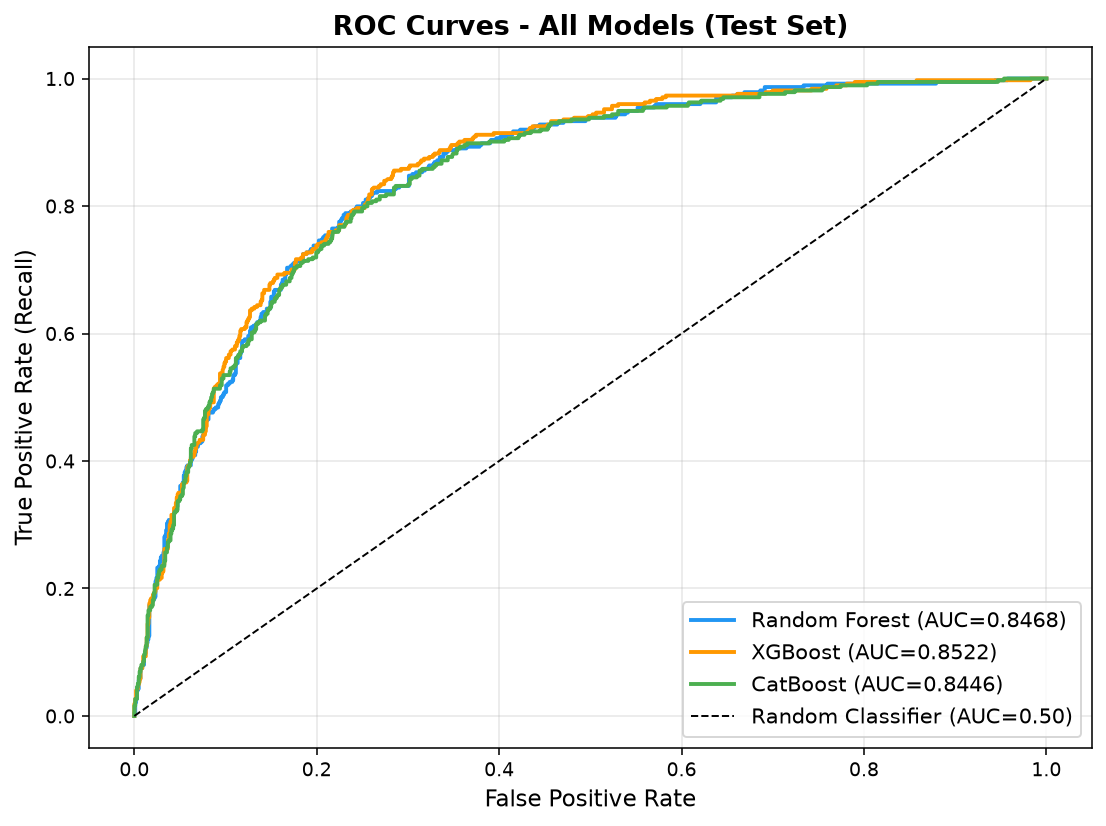

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, y_prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = all_results[model_name]['ROC-AUC']
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.4f})',
            color=colours[model_name], lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves - All Models (Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/10_roc_curves.png', bbox_inches='tight')
plt.show()

### 6.4 Precision-Recall Curves

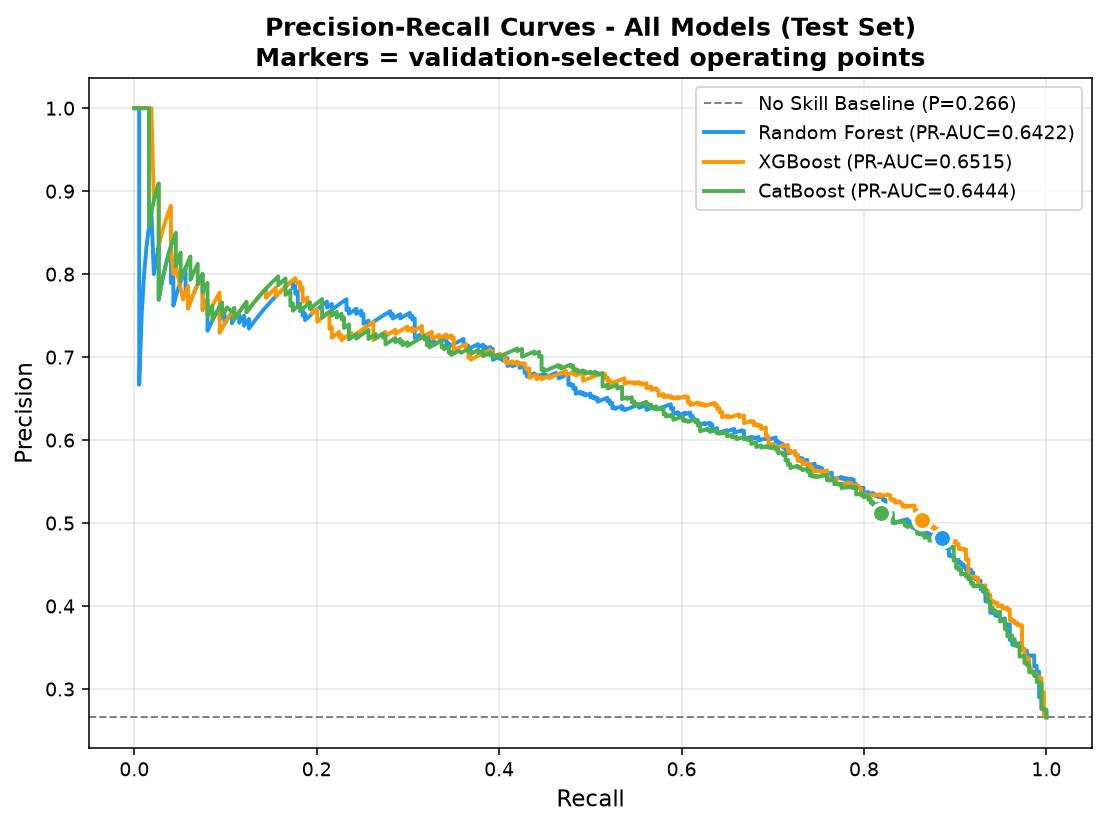

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

baseline_pr = y_test.mean()
ax.axhline(baseline_pr, color='grey', linestyle='--', lw=1,
           label=f'No Skill Baseline (P={baseline_pr:.3f})')

for model_name, y_prob in all_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = all_results[model_name]['PR-AUC']
    ax.plot(recall, precision, label=f'{model_name} (PR-AUC={pr_auc:.4f})',
            color=colours[model_name], lw=2)

# Mark each model's frozen operating point
for model_name, y_prob in all_probs.items():
    thr = thresholds_used[model_name]
    p = precision_score(y_test, (y_prob >= thr).astype(int), zero_division=0)
    r = recall_score(y_test, (y_prob >= thr).astype(int), zero_division=0)
    ax.scatter(r, p, s=90, color=colours[model_name], zorder=5,
               edgecolors='white', lw=1.8)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - All Models (Test Set)\n'
             'Markers = validation-selected operating points',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/11_pr_curves.png', bbox_inches='tight')
plt.show()

### 6.5 Confusion Matrices

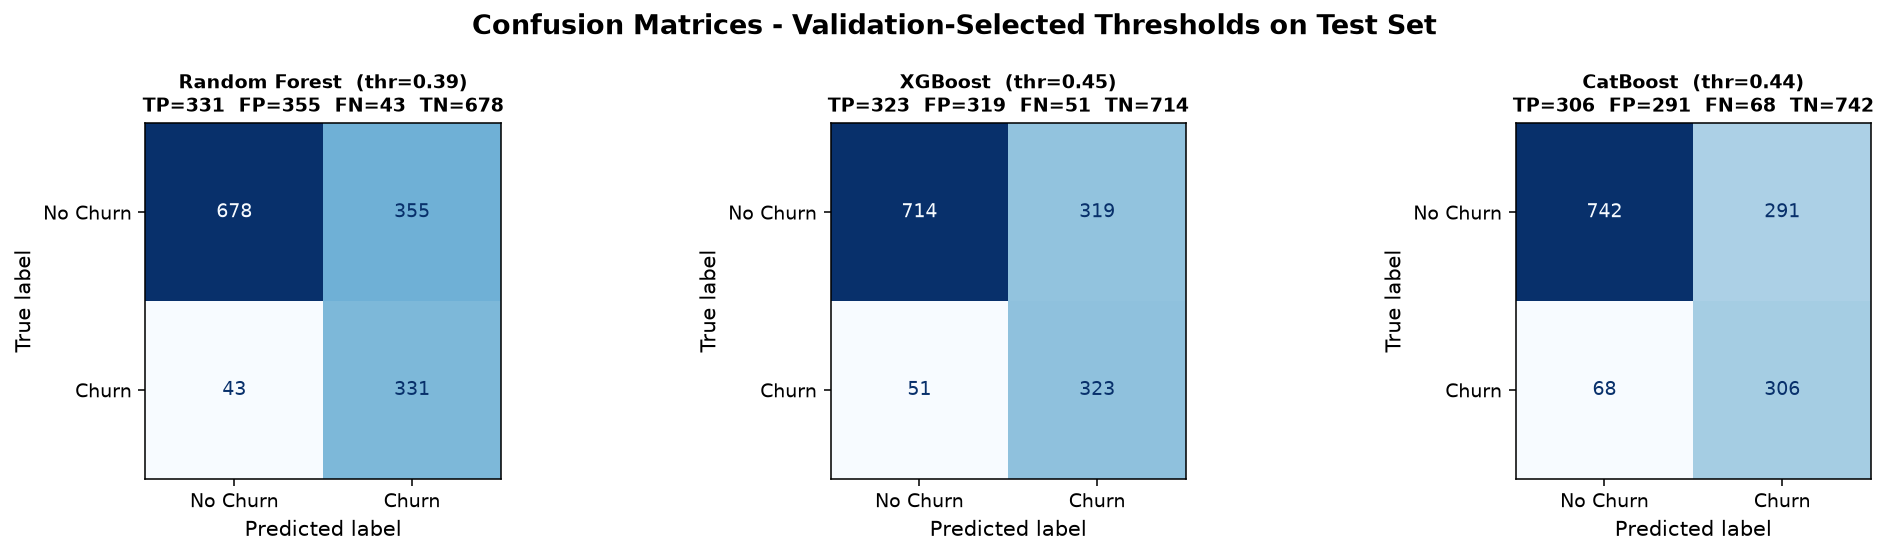

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, y_prob) in zip(axes, all_probs.items()):
    thr    = thresholds_used[model_name]
    y_pred = (y_prob >= thr).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['No Churn', 'Churn']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{model_name}  (thr={thr:.2f})\n'
                 f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices - Validation-Selected Thresholds on Test Set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/12_confusion_matrices.png', bbox_inches='tight')
plt.show()

### 6.6 Threshold Generalisation Analysis

This is the section the three-way split makes possible. For each model it compares:

- **Test F1 at the validation-selected threshold** — the honest, reportable number;
- **Test F1 at the test-optimal threshold** — what you would get by tuning on test.

The difference is the **optimism gap**: the amount by which test-set threshold tuning
inflates reported performance. Quantifying it is a defensible methodological
contribution, since much of the churn literature reports the second number as if it
were the first.

The threshold **shift** (how far the val-optimal and test-optimal cut-offs sit apart)
indicates how stable the operating point is across samples.

In [40]:
rows = []
for name, test_prob in all_probs.items():
    val_thr  = thresholds_used[name]
    val_prob = val_probs[name]

    val_f1_at_val_thr = f1_score(y_val, (val_prob >= val_thr).astype(int), zero_division=0)
    test_f1_at_val_thr = f1_score(y_test, (test_prob >= val_thr).astype(int), zero_division=0)

    test_thr, test_f1_at_test_thr = find_best_threshold(y_test, test_prob, metric='f1')

    rows.append({
        'Model'                : name,
        'Val thr'              : val_thr,
        'Val F1 @ val thr'     : val_f1_at_val_thr,
        'Test F1 @ val thr'    : test_f1_at_val_thr,
        'Test-opt thr'         : test_thr,
        'Test F1 @ test thr'   : test_f1_at_test_thr,
        'Optimism gap'         : test_f1_at_test_thr - test_f1_at_val_thr,
        'Threshold shift'      : abs(test_thr - val_thr),
    })

gen_df = pd.DataFrame(rows).set_index('Model')

print("=" * 96)
print("THRESHOLD GENERALISATION - validation-selected vs test-optimal thresholds")
print("=" * 96)
print(gen_df.round(4).to_string())
print()
print(f"Mean optimism gap    : {gen_df['Optimism gap'].mean():.4f} F1")
print(f"Mean threshold shift : {gen_df['Threshold shift'].mean():.3f}")
print()
print("Interpretation: the optimism gap is the F1 inflation that would result from")
print("selecting the decision threshold on the test set. Reported results in this")
print("study use the validation-selected threshold column.")

THRESHOLD GENERALISATION - validation-selected vs test-optimal thresholds
               Val thr  Val F1 @ val thr  Test F1 @ val thr  Test-opt thr  Test F1 @ test thr  Optimism gap  Threshold shift
Model                                                                                                                       
Random Forest     0.39            0.6069             0.6245          0.49              0.6497        0.0252             0.10
XGBoost           0.45            0.6201             0.6358          0.64              0.6499        0.0141             0.19
CatBoost          0.44            0.6010             0.6303          0.52              0.6425        0.0123             0.08

Mean optimism gap    : 0.0172 F1
Mean threshold shift : 0.123

Interpretation: the optimism gap is the F1 inflation that would result from
selecting the decision threshold on the test set. Reported results in this
study use the validation-selected threshold column.


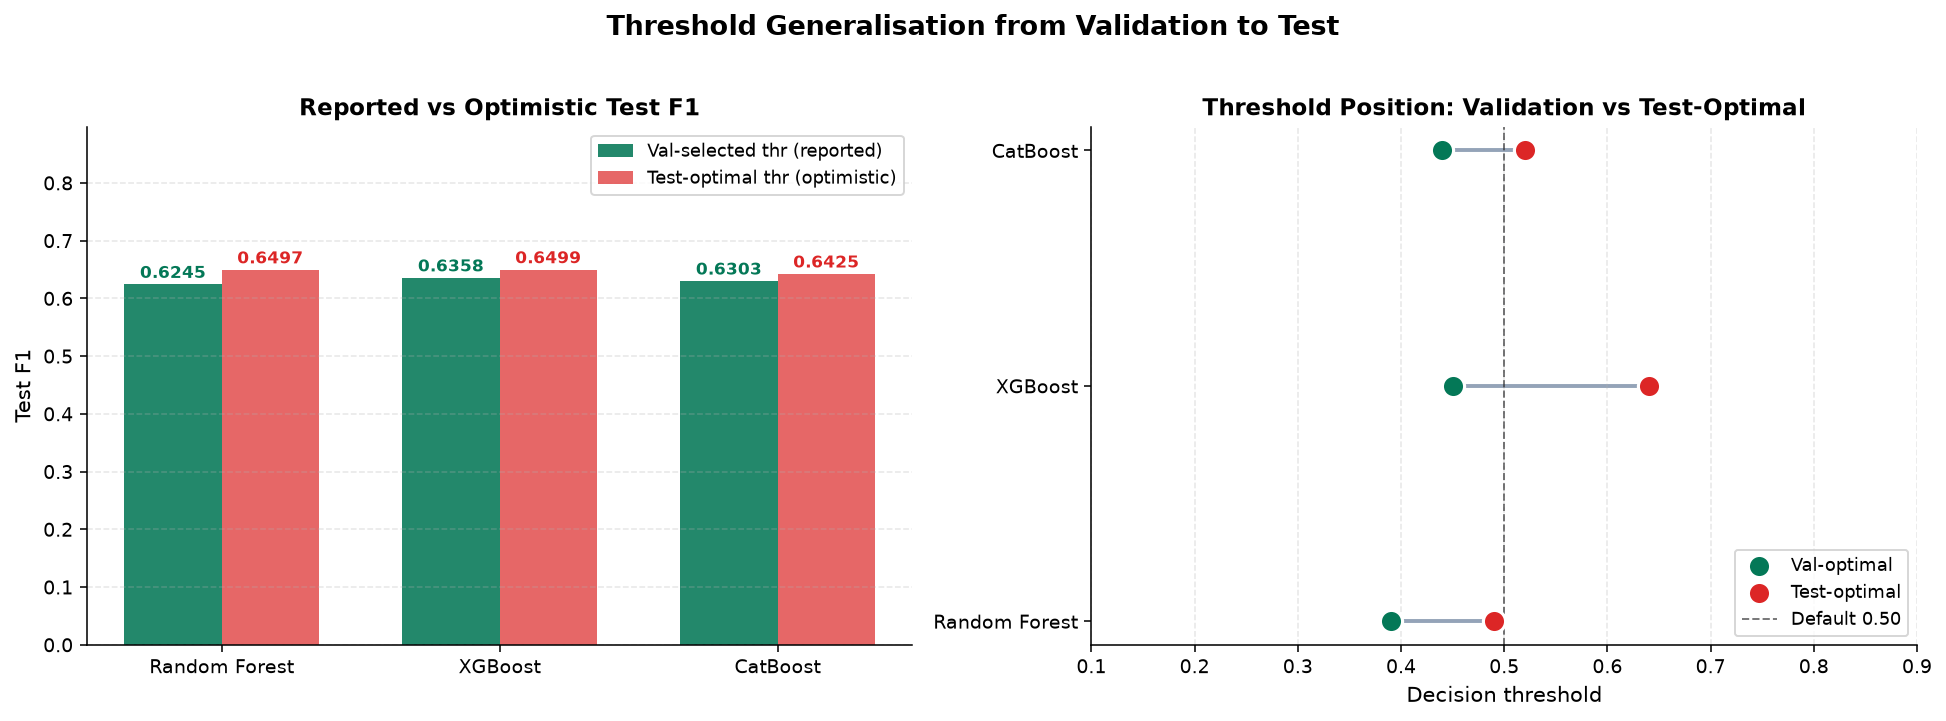

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: honest vs optimistic F1
x     = np.arange(len(gen_df))
width = 0.35
axes[0].bar(x - width/2, gen_df['Test F1 @ val thr'], width,
            color='#047857', alpha=0.88, label='Val-selected thr (reported)')
axes[0].bar(x + width/2, gen_df['Test F1 @ test thr'], width,
            color='#DC2626', alpha=0.7, label='Test-optimal thr (optimistic)')

for i, (v_honest, v_opt) in enumerate(zip(gen_df['Test F1 @ val thr'],
                                          gen_df['Test F1 @ test thr'])):
    axes[0].text(i - width/2, v_honest + 0.004, f'{v_honest:.4f}',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#047857')
    axes[0].text(i + width/2, v_opt + 0.004, f'{v_opt:.4f}',
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#DC2626')

axes[0].set_xticks(x)
axes[0].set_xticklabels(gen_df.index, fontsize=10)
axes[0].set_ylabel('Test F1')
axes[0].set_ylim(0, max(gen_df['Test F1 @ test thr']) * 1.38)
axes[0].set_title('Reported vs Optimistic Test F1', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: threshold positions
for i, name in enumerate(gen_df.index):
    axes[1].plot([gen_df.loc[name, 'Val thr'], gen_df.loc[name, 'Test-opt thr']],
                 [i, i], color='#94A3B8', lw=2, zorder=1)
    axes[1].scatter(gen_df.loc[name, 'Val thr'], i, s=130, color='#047857',
                    zorder=3, edgecolors='white', lw=1.6, label='Val-optimal' if i == 0 else '')
    axes[1].scatter(gen_df.loc[name, 'Test-opt thr'], i, s=130, color='#DC2626',
                    zorder=3, edgecolors='white', lw=1.6, label='Test-optimal' if i == 0 else '')

axes[1].axvline(0.50, color='#1C1C1E', ls='--', lw=1, alpha=0.6, label='Default 0.50')
axes[1].set_yticks(range(len(gen_df)))
axes[1].set_yticklabels(gen_df.index, fontsize=10)
axes[1].set_xlabel('Decision threshold')
axes[1].set_xlim(0.1, 0.9)
axes[1].set_title('Threshold Position: Validation vs Test-Optimal', fontweight='bold')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Threshold Generalisation from Validation to Test',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/13_threshold_generalisation.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Feature Importance Analysis

We analyse the best-performing model in detail to understand which features drive churn predictions.

The best-performing model is analysed in detail to understand which features drive
churn predictions.

In [42]:
all_metrics = pd.DataFrame(all_results).T
all_metrics

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Random Forest,Random Forest,0.39,0.717129,0.482507,0.885027,0.624528,0.846842,0.64215
XGBoost,XGBoost,0.45,0.737029,0.503115,0.863636,0.635827,0.852242,0.651469
CatBoost,CatBoost,0.44,0.744847,0.512563,0.818182,0.630278,0.844636,0.644373


In [43]:
# Best model selected by test F1 at the validation-chosen threshold
best_model_name = max(all_results, key=lambda k: all_results[k]['F1'])
print(f"Best model by test F1: {best_model_name} "
      f"(F1={all_results[best_model_name]['F1']:.4f} "
      f"@ thr={thresholds_used[best_model_name]:.2f})")

model_objects = {
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
    'CatBoost': cat_best,
}
best_model_obj = model_objects[best_model_name]
feature_names  = X_test.columns.tolist()

Best model by test F1: XGBoost (F1=0.6358 @ thr=0.45)


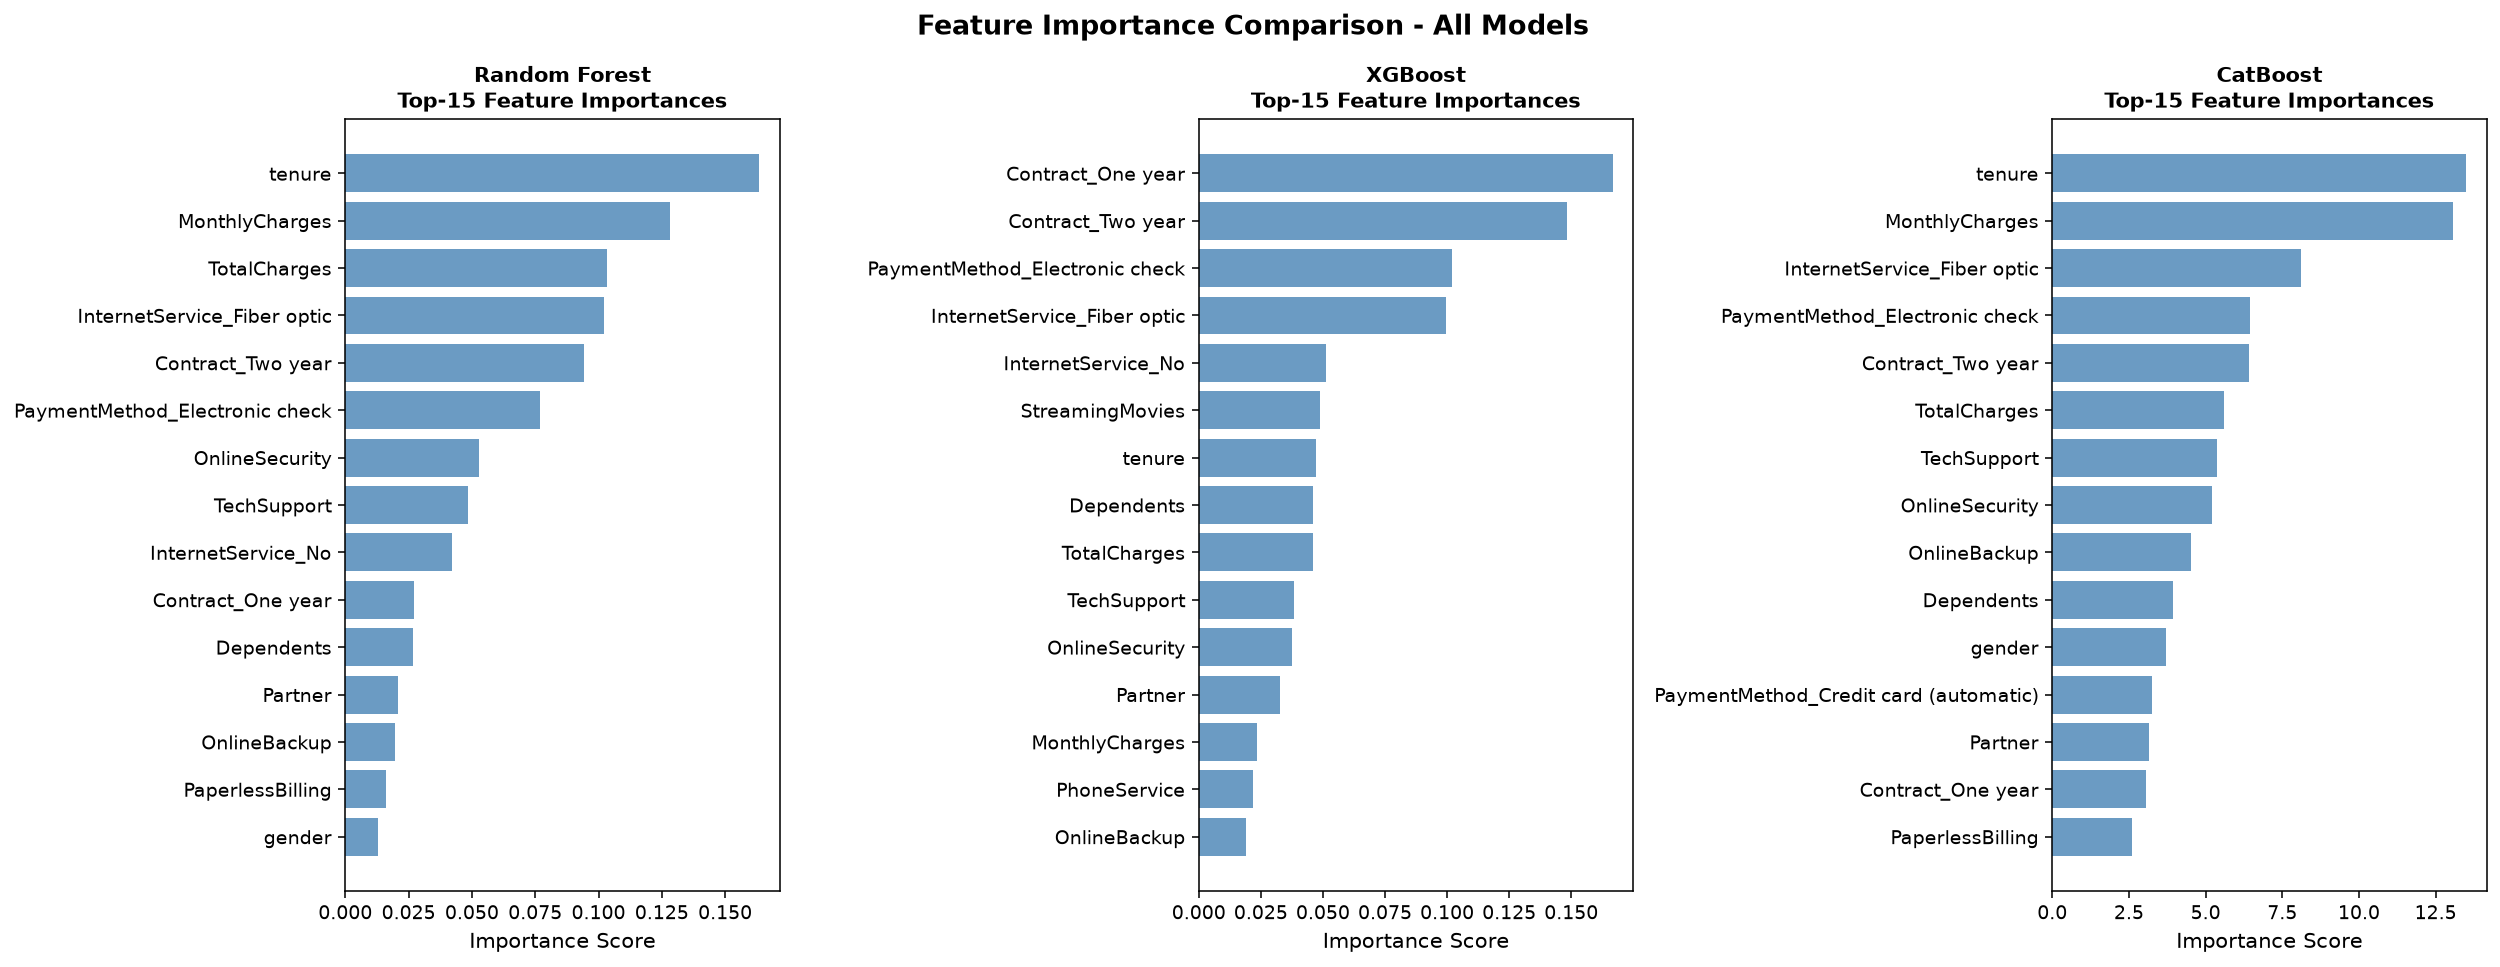

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (name, model) in zip(axes, model_objects.items()):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)

    ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', alpha=0.8)
    ax.set_title(f'{name}\nTop-15 Feature Importances', fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/14_feature_importances.png', bbox_inches='tight')
plt.show()

Top 15 Features - XGBoost:

                       Feature  Importance
             Contract_One year    0.166650
             Contract_Two year    0.148135
PaymentMethod_Electronic check    0.101862
   InternetService_Fiber optic    0.099678
            InternetService_No    0.051112
               StreamingMovies    0.048955
                        tenure    0.047092
                    Dependents    0.046108
                  TotalCharges    0.045849
                   TechSupport    0.038387
                OnlineSecurity    0.037671
                       Partner    0.032545
                MonthlyCharges    0.023628
                  PhoneService    0.021687
                  OnlineBackup    0.019082


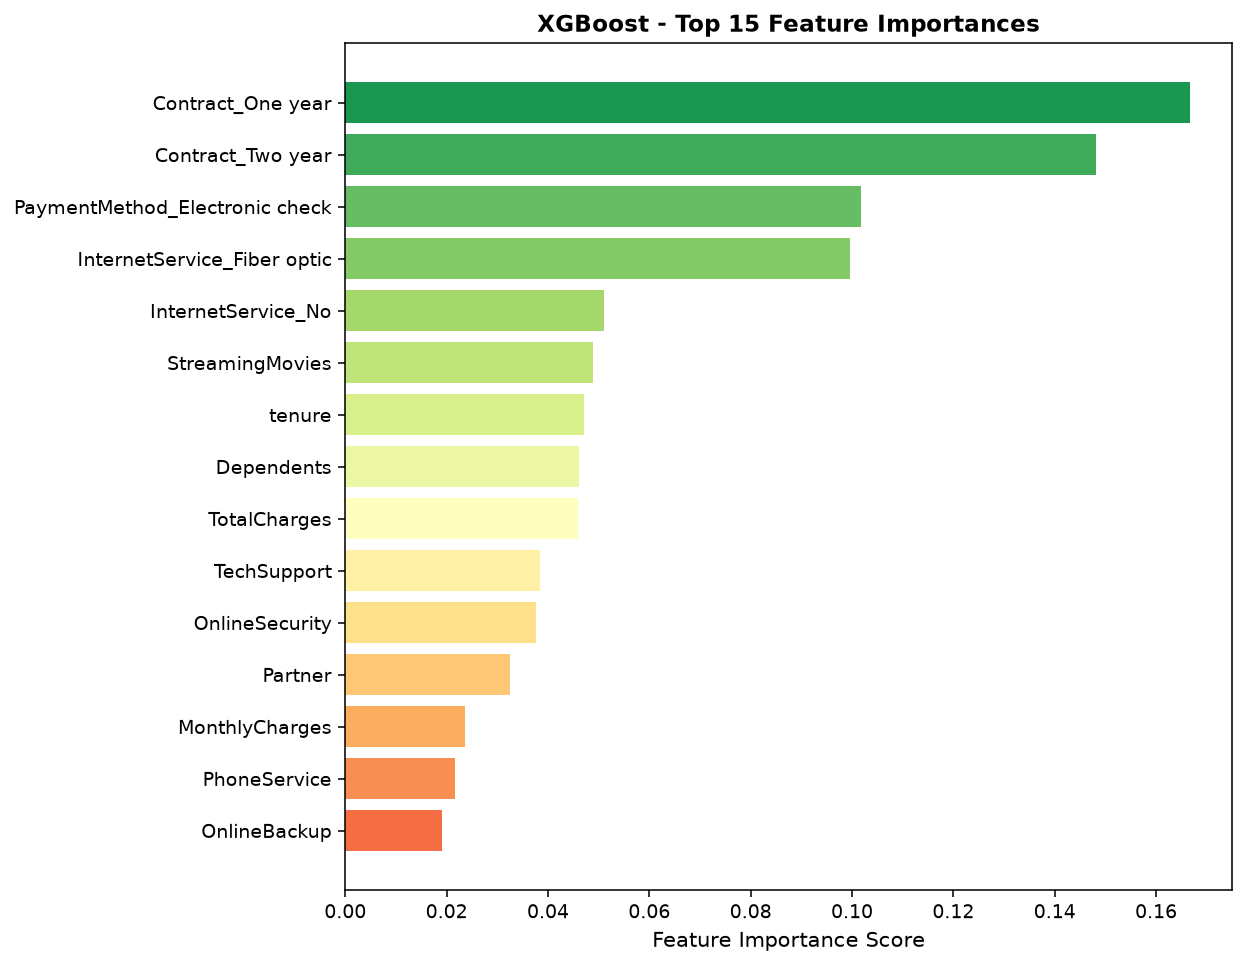

In [45]:
importances = best_model_obj.feature_importances_
fi_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=False))

print(f"Top 15 Features - {best_model_name}:\n")
print(fi_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top15 = fi_df.head(15).sort_values('Importance')
colours_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top15)))
ax.barh(top15['Feature'], top15['Importance'], color=colours_fi)
ax.set_title(f'{best_model_name} - Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('plots/15_best_model_feature_importance.png', bbox_inches='tight')
plt.show()

## 8. Optuna Tuning Visualisation

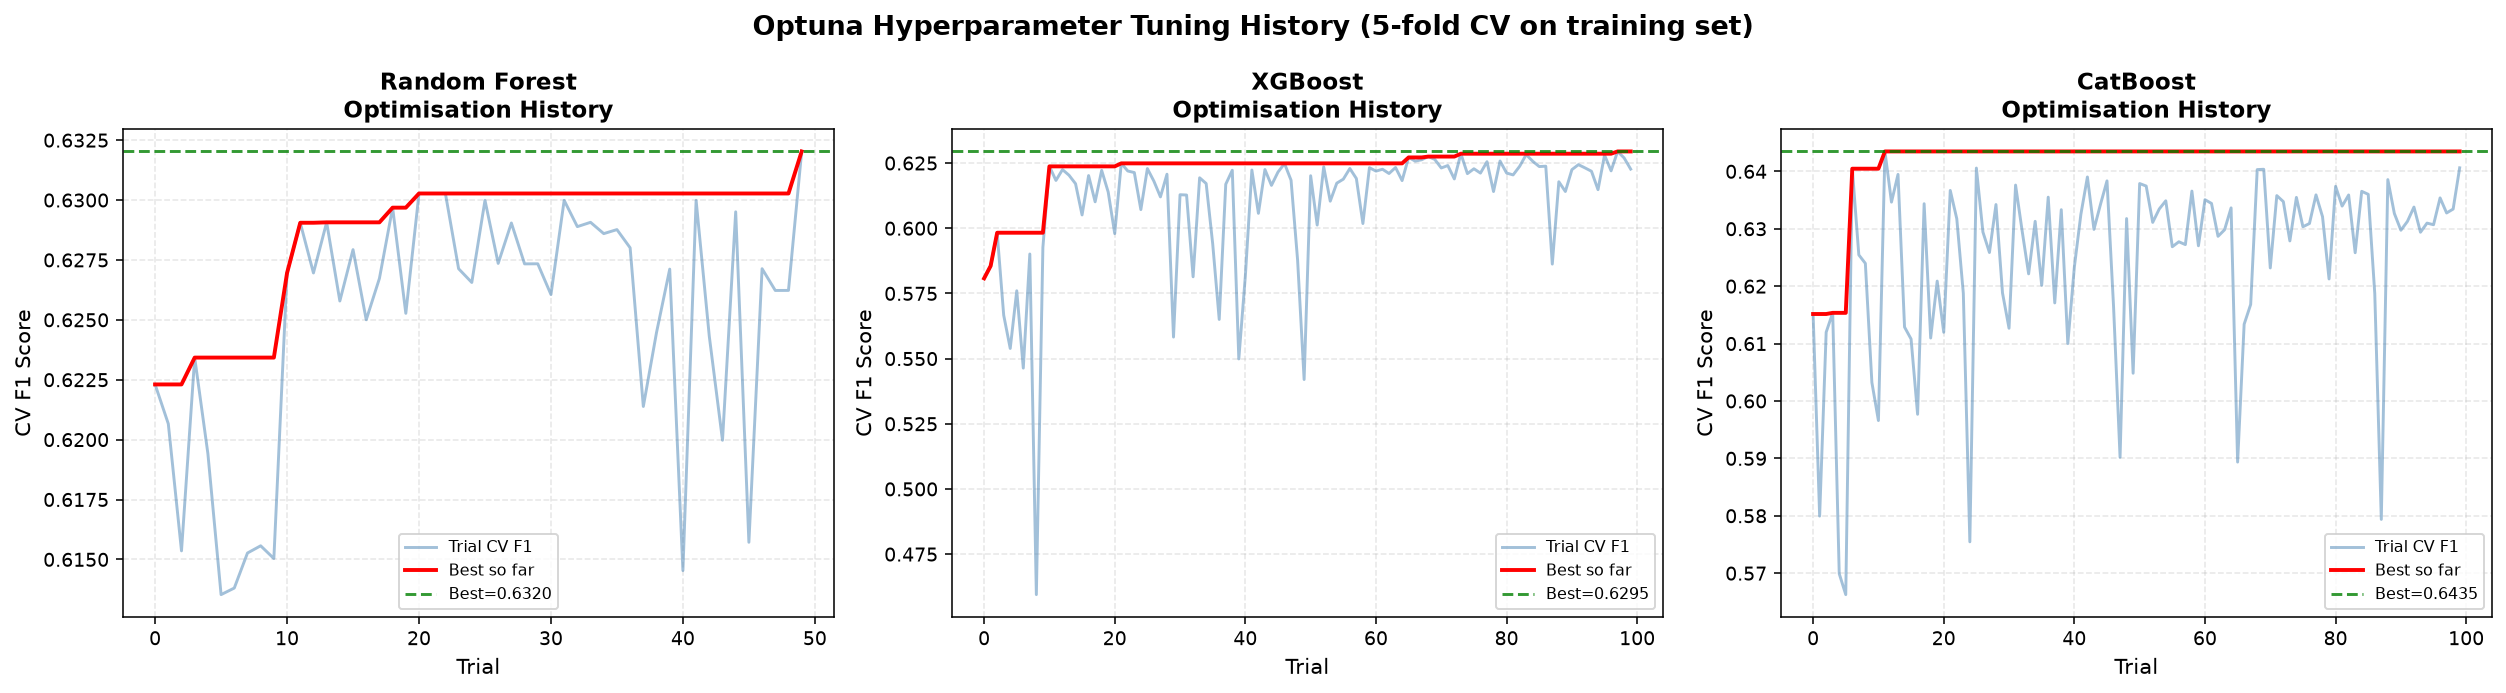

In [46]:
study_map = {'Random Forest': rf_study, 'XGBoost': xgb_study, 'CatBoost': cat_study}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, study) in zip(axes, study_map.items()):
    trial_vals = [t.value for t in study.trials if t.value is not None]
    best_vals  = np.maximum.accumulate(trial_vals)
    ax.plot(trial_vals, alpha=0.5, color='steelblue', label='Trial CV F1')
    ax.plot(best_vals, color='red', lw=2, label='Best so far')
    ax.axhline(study.best_value, linestyle='--', color='green', alpha=0.8,
               label=f'Best={study.best_value:.4f}')
    ax.set_title(f'{name}\nOptimisation History', fontweight='bold')
    ax.set_xlabel('Trial'); ax.set_ylabel('CV F1 Score')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, linestyle='--')

plt.suptitle('Optuna Hyperparameter Tuning History (5-fold CV on training set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/16_optuna_history.png', bbox_inches='tight')
plt.show()

## 9. Final Summary

In [47]:
print("=" * 84)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("Protocol: hyperparameters from 5-fold CV on train | threshold from validation |")
print("          metrics from test, threshold frozen")
print("=" * 84)

final_df = pd.DataFrame(all_results).T[
    ['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
].round(4)
print(final_df.to_string())

print("\n" + "=" * 84)
print(f"BEST MODEL: {best_model_name}")
print(f"  Threshold (from validation) = {thresholds_used[best_model_name]:.2f}")
for m in ['F1', 'Recall', 'Precision', 'ROC-AUC', 'PR-AUC']:
    print(f"  {m:<10s}= {all_results[best_model_name][m]:.4f}")

print("\n" + "-" * 84)
print("Threshold generalisation:")
print(f"  Mean optimism gap avoided by not tuning on test = "
      f"{gen_df['Optimism gap'].mean():.4f} F1")
print("-" * 84)

FINAL MODEL PERFORMANCE SUMMARY
Protocol: hyperparameters from 5-fold CV on train | threshold from validation |
          metrics from test, threshold frozen
              Threshold  Accuracy Precision    Recall        F1   ROC-AUC    PR-AUC
Random Forest      0.39  0.717129  0.482507  0.885027  0.624528  0.846842   0.64215
XGBoost            0.45  0.737029  0.503115  0.863636  0.635827  0.852242  0.651469
CatBoost           0.44  0.744847  0.512563  0.818182  0.630278  0.844636  0.644373

BEST MODEL: XGBoost
  Threshold (from validation) = 0.45
  F1        = 0.6358
  Recall    = 0.8636
  Precision = 0.5031
  ROC-AUC   = 0.8522
  PR-AUC    = 0.6515

------------------------------------------------------------------------------------
Threshold generalisation:
  Mean optimism gap avoided by not tuning on test = 0.0172 F1
------------------------------------------------------------------------------------
